<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Алексей! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span> 

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 3</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется.</span> 

## Модель для прогнозирования вероятности клика на рекламном баннере биржи Advantex

- Автор: Федоров Алексей Анатольевич
- Дата: 29.06.2026

<a id='цели-и-задачи-проекта'></a>
### Цели и задачи проекта

Платформа Advantex - это провайдер рекламных баннеров каждый показ которых оплачивается заказчиком - провайдером рекламы. Заказчик платит определённую цену за один клик конкретного баннера, которая определена заранее договором между ним и платформой Advantex. Платформа должна прогнозировать CTR - вроятность клика на банере:
$CTR = \frac{\text{Клики}}{\text{Показы}} \times 100\%$.
Чтобы участвовать в аукционе за рекламные слоты Web-сайтов и мобильных приложений. На аукцион платформа предоставляет CTR баннера и стоимость, которую она готова оплачивать провайдеру слота за клик. Выручка с клика определяется:

**Ожидаемый_доход = Ставка × Предсказанная_вероятность_отклика**.

Таким образом, очень важна точность вероятности клика, её максимальное совпадение с реальной вероятностью клика. Это позволит при подборе баннеров выбирать лучшие по произведению ставки на вероятность, чтобы оно было максимальным.


1. **Тип задачи:** бинарная классификация на несбалансированных класах, обучение с учителем (по размеченным данным).


2. **Задача**: Построение на основе датасета **ds_s16_ad_click_dataset.csv** модели, использующей логистическую регрессию или SVC для прогнозирования вероятности клика CTR (Click-Through Rate, коэфф. кликабельности) пользователей по рекламному баннеру в случае его размещения в выигранном на аукционе рекламном слоте Web-сайта или мобильного приложения.


1. **Цель:** максимизация прибыли (**Ожидаемый_доход = Ставка × Предсказанная_вероятность_отклика**) рекламной платформы Advantex от размещения баннеров через аукционы на рекламные слоты. Иными словами: максимизация произведения ставки на вероятность за счёт **максимально точной и реалистичной оценки этой вероятности**.


2. **Целевая переменная**: `click`. 1 — клик был, 0 — клика не было.


3. **Метрики качества модели по вероятности клика**:
    
    реальные (калиброванные) вероятности кликов по баннерам - главный приоритет:
   - **Основная**: Log Loss - интегральная оценка качества вероятностей (штрафует за переуверенность);
   - **Вторая основная**: Brier Score - среднеквадратичная ошибка вероятностей;
   - **Дополнительные**:
       - ECE (Expected Calibration Error) -  среднее отклонение предсказанной вероятности от фактической частоты;
       - MCE (Maximum Calibration Error) — максимальное локальное отклонение.

4. **Метрики качества модели по разделяющей способности**:
    
    есть дизбаланс классов, поэтому:
    - PR_AUC — площадь под Precision-Recall кривой (устойчива к дисбалансу, не требует порога);
    - ROC_AUC — вспомогательная оценка ранжирования.
    
5. **Диагностические метрики (при пороге, подобранном под бизнес-логику)**:
    - F2-score — приоритет Recall над Precision (пропуск клика дороже лишнего показа);
    - Recall, Precision — для понимания баланса ошибок.
    
6. **Требования к модели (относительно baseline = DummyClassifier):**
    - PR_AUC выше на 0.05 - 0.1;
    - ROC AUC > 0.5;
    - Log Loss ниже на 0.05 - 0.1;
    - Bier Score ниже;
    - ECE - ниже на 0.02 - 0.03;
    - MCE - ниже на 0.05 - 0.1;
    - F2-score - выше.   
    
    
7. **Ориентировочные метрики**

| Метрика  | Единицы   | Baseline (примерно)     | Требование           | Целевое значение    |
|----------|-----------|-------------------------|----------------------|---------------------|
| PR AUC   | 0…1, абс.  | 0.17 (=CTR)            | +0.05...0.10         | 0.22...0.27         |
| ROC AUC  | 0…1, абс.  | 0.50                   | > 0.5 заметно        | 0.65...0.75+        |
| Log Loss | ≥ 0, абс.  | ~0.45                  | −0.05...0.10         | ~0.35...0.40        |
| Brier    | 0…1, абс.  | ~0.14                  | ниже baseline        | < 0.14              |
| ECE      | 0…1, абс.  | ~0                     | < 0.02...0.03        | < 0.03              |
| MCE      | 0…1, абс.  | —                      | < 0.05...0.10        | < 0.10              |

<a id='описание-данных'></a>
### Описание данных
Датасет ds_s16_ad_click_dataset.csv собран из систем показа рекламы и логирования взаимодействий пользователей с рекламными баннерами.

#### Идентификаторы и временные метки

- `id` — уникальный идентификатор записи о показе баннера.
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

#### Характеристики рекламной площадки (Site)

- `site_id` — идентификатор веб-сайта, на котором был показан баннер.
- `site_domain` — домен веб-сайта.
- `site_category` — тематическая категория веб-сайта.

#### Характеристики рекламируемого приложения (App)

- `app_id` — идентификатор рекламируемого мобильного приложения.
- `app_domain` — домен рекламируемого приложения.
- `app_category` — категория рекламируемого приложения.

#### Характеристики устройства и соединения пользователя

- `device_id` — идентификатор браузера или устройства.
- `device_ip` — IP-адрес устройства.
- `device_model` — модель устройства.
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК.
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

#### Характеристики рекламного баннера и аукциона

- `C1` — анонимизированный признак, характеризующий контекст показа.
- `banner_pos` — позиция баннера на веб-странице.
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

#### Машинно-сгенерированные признаки (ML Features)

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков.
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

#### Целевая переменная

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру: `1` — клик был, `0` — клика не было.

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

##### Подготовка полного requirements.txt с транзитными зависимостями по базовым версиям библиотек

In [1]:
# в облаке YC старый pip, поэтому обновляем: нам будет нужен --dry-run
%pip install --upgrade pip

     |████████████████████████████████| 1.8 MB 2.0 MB/s eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 21.1.3
    Uninstalling pip-21.1.3:
      Successfully uninstalled pip-21.1.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
# проверяем обновлённость pip, чтобы работал --dry-run
import pip
print(pip.__version__)

26.0.1


In [3]:
# базовые зависимости для EDA и ML
base_libs = (    
    "numba==0.58.1", # надо для scikit-learn 1.6.1 и pandas
    "pyarrow==14.0.1", # добавлено для поддержки типа данных string в pandas
    "numpy==1.25.2",
    "pandas==2.1.4",
    "jinja2>=3.1.2",
    "phik==0.12.5",
    "seaborn==0.13.2",
    "statsmodels==0.14.1",
    "matplotlib==3.9.2",
    "scikit-learn==1.6.1",
    "ipykernel",
    "joblib",
)

In [4]:
# Тут получим транзитивные зависимости через --dry-run и построим полный requirements.txt
# затем, этот код можно хакомментить, он разовый, до следующего изменения базовых зависимостей
# и, далее, раскомментить ячейку %pip install -r requirements.txt
# она будет ставить зафиксированные полные зависимости

import sys
import os
import json
import subprocess

print("Генерация полного списока зависимостей...")

try:
    # Используем --dry-run и --report. 
    # Это НЕ устанавливает пакеты, а только вычисляет идеальный граф зависимостей.
    cmd = [
        sys.executable, "-m", "pip", "install", 
        "--dry-run",         
        "--report", "full_report.json",
        *base_libs
    ]
    
    subprocess.check_call(cmd)
    
    with open("full_report.json", 'r') as f:
        report = json.load(f)
    
    with open('requirements.txt', 'w') as f:
        # Сортируем для красоты
        installs = sorted(report['install'], key=lambda x: x['metadata']['name'].lower())
        for item in installs:
            name = item['metadata']['name']
            version = item['metadata']['version']
            f.write(f"{name}=={version}\n")
            
    print("\n✅ Полный с транзитивными зависимостями requirements.txt создан!")
    print("-" * 30)
    with open('requirements.txt', 'r') as f:
        print(f.read())
    print("-" * 30)

except Exception as e:
    print(f"Ошибка: {e}")

Генерация полного списока зависимостей...
Would install numpy-1.25.2 packaging-26.2 pandas-2.1.4

✅ Полный с транзитивными зависимостями requirements.txt создан!
------------------------------
numpy==1.25.2
packaging==26.2
pandas==2.1.4

------------------------------


Зависимости здесь: https://k8s.jupyterhub.praktikum-services.ru/user/user-0-27358077/edit/requirements.txt

In [5]:
# !cat requirements.txt

In [6]:
%pip install -r requirements.txt 

  Using cached numpy-1.25.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pandas-2.1.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 71.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 89.8 MB/s  0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.2
    Uninstalling pytz-2026.2:
      Successfully uninstalled pytz-2026.2
  Attempting uninstall: tzdata━━━━━━━━━━━━━━━━━━ 0/7 [pytz]
    Found existing installation: tzdata 2026.20m 0/7 [pytz]
    Uninstalling tzdata-2026.2:━━━━━━━━━━━━━ 0/7 [pytz]
      Successfully uninstalled tzdata-2026.2 0/7 [pytz]
  Attempting uninstall: six━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [tzdata]
    Found existing installation: six 1.17.0━━━━━━━━━━━━━━━━━━━ 1/7 [tzdata]
    Uninstalling six-1.17.0:━━━━━━━━━

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~У меня нет файла `requirements.txt`, его нужно явно создать в проекте.\
Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.\
Может пригодится:~~</font>
```python
with open("requirements.txt", "w") as f:
    f.write(requirements) # requirements строковая переменная.
```

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Павел!

Обычно тетрадь работает по другой схеме. Но в этот раз она создана по требованиям задания. Само по себе задание было ошибочным, и если делать 1 в 1 по нему, то ничего работать не будет, а сервер просто ляжет.

**requirements.txt** создан с применением изоляции окружения через Dry-run и он у вас есть, так как вы работаете в облаке, в том же окружении. По негласному соглашению работы сдаются в облаке. Всё, что есть в данной конфигурации облака в одинаковой степени есть у всех пользователей.
Вот он: https://k8s.jupyterhub.praktikum-services.ru/user/user-0-27358077/edit/requirements.txt

Лежит рядом c данным ipynb-файлом. Если вы забираете ipynb к себе из облака локально, то должны забрать и все связанные файлы и настроить себе venv и ядро сами.

Требования шаблона вот эти:
**"Создайте файл requirements.txt с фиксированными версиями всех пакетов.
Импортируйте все необходимые библиотеки."**

По ним и сделано.

Иными словами, если вы открыли этот ipynb в облаке, то все связанные ресурсы уже лежат там же рядом. А если вы скопировали файл в локальное окружение из облака, то настройка этого окружения - ваша отвественность. Для нас эти действия нигде в задании не прописаны. Например: могли бы быть требования - уложить все нужные файлы в Git Hub и написать readme.md. Эта процедура не предусморена. Негласно предусмотрена сдача в облаке Яндекс Клауд и все ей следуют. Это значит, что всё, что есть в облаке, в равной степени есть у всех.

Поэтому, боюсь, **я не понимаю вопроса**. Я всё сделал по инструкции исправив её и приведя в рабочее состояние. Всё в облаке. requirements.txt тут же рядом с данным файлом у вас есть, если вы смогли туда зайти под своей учёткой. Или, я чего-то не пониммаю?

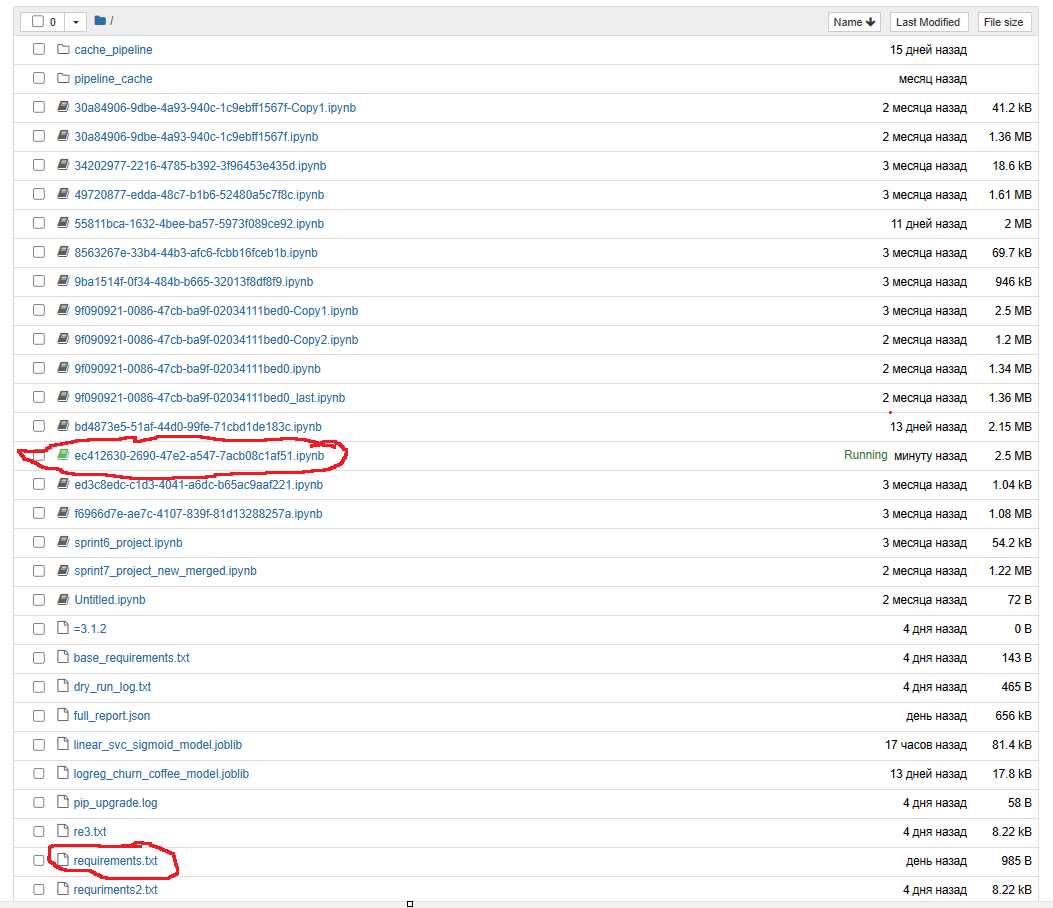

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<font color='red'>Алексей,
- во-первых, у нас разные рабочие директории (для студентов и ревьюеров запускаются разные контейнеры) и передаётся только файл `.ipynb`
- во-вторых, это сделано для того, что бы `requirements.txt` разных студентов и разных проектов не конфликтовали.

Поэтому, поскольку весь проект выполняется в этой тетрадке, то задание  "Создайте файл requirements.txt с фиксированными версиями всех пакетов." нужно выполнять буквально: В ноутбуке создать файл `requirements.txt` с зависимостями конкретно под код в этом конкретном ноутбуке проекта, а код должен полностью исполняться В JupyterHub Практикума.\
Может пригодится:</font>
```python
with open("requirements.txt", "w") as f:
    f.write(requirements) # requirements строковая переменная.
```

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Павел, по поводу: **"выполнять буквально"**, я уже объяснил, к чему это приводит. По моему мнению, у того, кто написал проект к этому спринту, неполное профессиональное соотвествие. В отличие от этого, мой код работает правильно. Я доказал это своим кодом.

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Добрый день, Павел!

Я пытался это выяснить, как и многое другое **с декабря 2025**. Нас отфутболивают или игнорят. 
Способ сдачи работ с pandas до настоящего момента ни в одном спринте не определён. Я многократно писал по этому вопросу и в отзывах, и в поддержку и менеджеру курса Сергею Трушу и кураторам. Ничего вразумительного мне не сказали.

Поэтому, могу пояснить здесь только следующее:

  **1)** по негласному скользкому и мутному соглашению сторон сдача этих работ осуществляется строго в облаке Яндекс Клауд на Jupyter 6.4.0;
  
  **2)** инфроструктура контролируется Яндексом, у меня нет к ней админского доступа, нам не разъясняется, как она настроена и работает и повлиять на это я никак не могу;
  
  **3)** сегодня задал вопрос в саппорт, меня зафутболили к менеджеру Сергею Трушу, а его нет. Вот диалог:
  
  ```
  --- Я>
  Иными словами: ipynb копируется в домашнюю директорию ревьювера, а после проверки обратно? Или, он заходит в ту же директорию?
Благодарим за ожидание.

--- Яндекс саппорт>
К сожалению, не сможем подсказать, в каком виде работу получает ревьюер.

Напишите, пожалуйста, своему куратору в мессенджере — он свяжется с ревьюером по вашему вопросу и подскажет, в каком виде работа приходит ему на проверку.

Если у вас ещё остались какие-либо вопросы — пишите, мы на связи.
  ```
  
  Как видите: меня в очередной раз зафутболили. Хотя, **они обязаны знать, как эта инфроструктура настроена или, хотя бы, кто её настраивает**;
  
  **4)** на основании выше сказанного: я могу только догадываться, что там происходит. Я же не Ванга! Я думаю головой, мыслю логически;
  
  **5)** **я догадываюсь**: когда жмётся кнопка "Отправить новую версию", то ipynb копируется в домашнюю папку виртуальной машины ревьювера из моей домашней папки. А когда вы завершаете ревью, то копируется обратно ко мне. Почему это, и следствия для сдачи работ, нигде нельзя прописать: я не понимаю. Так же, почему нас футболят;
  
  **6)** Павел, есть **очень большая просьба**: предже чем писать в моей работе в больших количествах необоснованные красные и жёлтые и во всех цветах радуги замечания, **пожалуйста**, если вы находитесь в начале тетрадки, то пролистайте тетрадку сначала вниз и ознакомьтесь с моей работой. Если же вы находитесь в середине тетрадки, то пролистайте сначала мою тетрадку вверх, чтобы понять, не сделано ли оно уже у меня ранее. Это экономит много времени и сил. Нам обещали 5 часов в неделю рабочего времени, а тут выходят все 40 и более;
  
  **7)** ознакомление с тетрадкой - это не просто благоволение ко мне, а это ваша **должностная обязанность**;
  
  **8)** с данным замечанием никак не могу соласиться. А именно, вы пишите "что все зависимости нужно устанавливать до импортов...". Пожалуйста, см. пунт 6: **пролистайте, пожалуйста мою тетрадку вверх**. Там всё это уже сделано. Вы просто не ознакомились с моей работой в полном объёме. И пишите мне, что я этого не сделал. А я именно это сделал и в полном объёме!
  
  **8)** если возникли трудности с прочтением моей тетрадки, то **поясню**: вам необходимо:
  - **разово выполнить ячейку `[1]`**;
  - **раскомментить и разово выполнить ячейку `[4]`, вернуть коммент обратно на `[4]`**;
  - **перезапустить ядро Jupyter и дождаться, пока тетрадка исполнится (примерно 4 минуты, может быстрее), на всякий случай, пролистать и убедиться, что ничего не упало**;
  
**9)** данный код выше, комментирован пояснениями, просто, забыли пролистать мою тетрадку вверх;

**10)** вы многократно, **как заклинание**, повторяете один и тот же код:
```
with open('requirements.txt', 'w') as f:
```
если бы вы пролистали мою тетрадку выше, то увидели бы, что этот код уже написан;

**11)** более того: я выполнил телефонный звонок на общий официальный номер Яндекса **8-800-700-93-29** и пояснил о проблемах сдачи проектов, неоднократно. В ответ мне сообщили, что единоличным 100%-ым владельцем курса Data Science Extended является менеджер Сергей Труш: он нас чаржит по дньгам за курс и он полностью отвечает за то, как проводится курс, как принимаются и сдаются работы, и только он в праве вносить изменения и разрешать спорные ситуации. Поэтому, в любом случае, решающее слово за менеджером курса.

##### Импорт зависимостей

In [7]:
import calendar
import contextlib
import gc
import os
import sys
import time
import warnings
from dataclasses import dataclass
from functools import reduce
from operator import mul
from itertools import combinations

import joblib
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from IPython.display import HTML, Markdown, display_html
from joblib import Memory
from matplotlib.ticker import PercentFormatter
from phik import phik_matrix
import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.feature_selection import RFECV, SequentialFeatureSelector, VarianceThreshold
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge, SGDRegressor
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    fbeta_score,
    make_scorer,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import calibration_curve, CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    StratifiedKFold,
    cross_validate,
    train_test_split,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, MinMaxScaler, OneHotEncoder, SplineTransformer,
    StandardScaler, TargetEncoder)
from sklearn.svm import LinearSVC, SVC
from sklearn.utils.validation import check_is_fitted
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from tqdm.auto import tqdm

<span style="color: blue; font-weight: bold">Комментарий ревьюера 3: </span>  ❌\
<span style="color: red">
Алексей, спасибо, что поделился своим взглядом на проблему, но:\
твой код не исполняется на платформе Практикума.\
</span>

##### Версии основных библиотек

In [8]:
print(
    f"Путь к Python: {sys.executable}",
    f"Версия Python: {sys.version}",
    f"Текущий путь: {os.getcwd()}",
    f"pandas: {pd.__version__}",
    f"numpy: {np.__version__}"
    f"\n\tБэкенд pandas (plotting): {pd.options.plotting.backend}",
    f"phik: {phik.__version__}",
    f"matplotlib: {matplotlib.__version__}",
    f"seaborn: {sns.__version__}",
    f"sklearn: {sklearn.__version__}",
sep='\n')

Путь к Python: /opt/conda/bin/python
Версия Python: 3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0]
Текущий путь: /home/jovyan/work
pandas: 2.1.4
numpy: 1.25.2
	Бэкенд pandas (plotting): matplotlib
phik: 0.12.5
matplotlib: 3.9.2
seaborn: 0.13.2
sklearn: 1.6.1


<a id='общие-функции'></a>
### Общие функции

<a id='базовые'></a>
#### Базовые

In [9]:
def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = set(ints or []) | set(
        data_frame.select_dtypes(include="integer").columns
    )
    floats_actual = (
        set(floats or [])
        | set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual
    cats_actual = set(cats or []) | set(
        data_frame.select_dtypes(include=["object", "string"]).columns
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame

<a id='базовый-eda'></a>
#### Базовый EDA

In [10]:
def normalize_text_cols(df, col_names, to_lower=True):
    """
        Конвертирует колонки col_names в string, обрезает пробелы с концов и нормализует пробелы внутри строк.
        Если задано to_lower, то приводит к нижнему регистру.
    """
    for name in col_names:        
        df[name] = df[name].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
        if to_lower:
            df[name] = df[name].str.lower()
            
def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def get_quasi_consts_numeric(df, names, threshold=0.1):
    vs_quasi = VarianceThreshold(threshold=threshold)     
    numerical_data = df[list(names)]
    vs_quasi.fit(numerical_data)
    return [col for col, keep in zip(names, vs_quasi.get_support()) if not keep]

def get_quasi_consts_categories(df, names):
    return [col for col in list(names)
                      if df[col].value_counts(normalize=True).iloc[0] > 0.90]

#### Статистический анализ

In [11]:
def check_vif(df, fields, top=10):
    """Расчет фактора инфляции дисперсии (VIF) для проверки мультиколлинеарности.

    Интерпретация значений VIF:
    - VIF = 1: коллинеарность отсутствует.
    - 1 < VIF <= 5: умеренная коллинеарность (допустимо).
    - VIF > 10: критический уровень, признак рекомендуется удалить.

    Важно: функция удаляет строки с пропусками (dropna).
    """
    df_vif = df[list(fields)].astype(float).dropna()

    df_with_const = add_constant(df_vif)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_vif.columns

    vif_data["VIF"] = [
        variance_inflation_factor(
            df_with_const.values, df_with_const.columns.get_loc(col)
        )
        for col in df_vif.columns
    ]

    return vif_data.sort_values(by="VIF", ascending=False).head(top)

#### Обучение

In [12]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Совместимый с новыми joblib патч через print_progress."""
    original_print_progress = joblib.parallel.Parallel.print_progress

    def patched_print_progress(self):
        # n_completed_tasks обновляется joblib'ом
        tqdm_object.n = self.n_completed_tasks
        tqdm_object.refresh()
        return original_print_progress(self)

    joblib.parallel.Parallel.print_progress = patched_print_progress
    try:
        yield tqdm_object
    finally:
        joblib.parallel.Parallel.print_progress = original_print_progress
        tqdm_object.close()
        
def sigmoid(x):
    return 1 / (1  + np.exp(-x))

##### Настройки библиотек

In [13]:
memory = Memory(location='./cache_pipeline', verbose=0)
sns.set_theme(style="whitegrid") # светлосерая сетка

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

In [14]:
LOCAL_DATA_FILE_PATH = '/datasets/ds_s16_ad_click_dataset.csv'
S3_DATA_FILE_PATH = 'https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv'
SEED = 42
TARGET = 'click'

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [15]:
data_path = LOCAL_DATA_FILE_PATH if os.path.exists(LOCAL_DATA_FILE_PATH) else S3_DATA_FILE_PATH
df = pd.read_csv(data_path, decimal='.', sep=',', skipinitialspace=True)
df_shape = df.shape
print(f'✅ Датасет загружен с "{data_path}" содержит: {df_shape[0]} строк')

✅ Датасет загружен с "/datasets/ds_s16_ad_click_dataset.csv" содержит: 50000 строк


## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.


In [16]:
df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

In [17]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [18]:
df.tail()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
49995,9.452834e+18,1,14103023,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,2.471707,A,6.971072,0,0.598654,0.897131,Y,1.102908,-0.063549,0.164935
49996,9.487581e+18,0,14103023,1005,1,0a742914,510bd839,f028772b,ecad2386,7801e8d9,...,0.380915,E,-1.829184,1,0.156171,0.181065,Y,0.136576,0.279587,0.193894
49997,9.895353e+18,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,d36838b1,0e8616ad,...,0.582656,E,-1.839117,1,-0.358271,0.472134,Z,0.385089,-0.094572,0.123317
49998,9.911007e+17,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,3c4b944d,2347f47a,...,-0.502279,B,4.263653,1,-1.567715,-0.997265,Z,-0.314288,0.267059,0.407779
49999,9.965090e+18,0,14103023,1005,1,57fe1b20,5b626596,f028772b,ecad2386,7801e8d9,...,0.078363,B,-5.710199,1,-2.015219,-0.991569,X,0.083858,-0.014856,-0.194617


👉 Загружено **50 000 строк и 34 признака**, данные соотвествуют описанию, имена колонок в snake_case. Нужно исправить строковые типы данных, чтобы избавиться от расточительного типа object.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

In [19]:
normalize_text_cols(df, df.select_dtypes(include=['object']).columns)

In [20]:
df.dtypes

id                         float64
click                        int64
hour                         int64
C1                           int64
banner_pos                   int64
site_id             string[python]
site_domain         string[python]
site_category       string[python]
app_id              string[python]
app_domain          string[python]
app_category        string[python]
device_id           string[python]
device_ip           string[python]
device_model        string[python]
device_type                  int64
device_conn_type             int64
C14                          int64
C15                          int64
C16                          int64
C17                          int64
C18                          int64
C19                          int64
C20                          int64
C21                          int64
ml_feature_1               float64
ml_feature_2        string[python]
ml_feature_3               float64
ml_feature_4                 int64
ml_feature_5        

✅ Строковые типы данных исправлены, сами строки нормализованы и приведены к нижнему регистру.

👉 Номализацию строк добавить в трансформер.

In [21]:
df['id'].is_unique

True

In [22]:
df.duplicated().sum()

0

id уникальный а полных явных дубликатов нет. После проверки id можно удалить, так как колонка не нужна для обучения.

In [23]:
df = df.drop('id', axis=1)
df.duplicated().sum()

0

✅ Удалили id. Явных дубликатов нет.

👉 Удаление id добавить в трансформер.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Есть проблема с hour: его нужно преобразовать в datetime, а потом разбить на компоненты, чтобы получились признаки, объясняющие целевую переменную. 

In [24]:
df['hour'] = pd.to_datetime(df['hour'].astype(str).str.zfill(8), format='%y%m%d%H')

In [25]:
display(df['hour'].head())
display(df['hour'].tail())

0   2014-10-21
1   2014-10-21
2   2014-10-21
3   2014-10-21
4   2014-10-21
Name: hour, dtype: datetime64[ns]

49995   2014-10-30 23:00:00
49996   2014-10-30 23:00:00
49997   2014-10-30 23:00:00
49998   2014-10-30 23:00:00
49999   2014-10-30 23:00:00
Name: hour, dtype: datetime64[ns]

✅ Преобразовали hour в datetime.

In [26]:
df["year"] = df["hour"].dt.year
df["month"] = df["hour"].dt.month
df["day"] = df["hour"].dt.day
df["hour_of_day"] = df["hour"].dt.hour
df["dayofweek"] = df["hour"].dt.dayofweek

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Верно, что "hour" стал действительно часом.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> У нас данных за 10 дней. "year","month"  — константные признаки.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Павел, сейчас мы находимся в EDA на стадии Ознакомления с данными. Вот бриф:
```
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.
```

Поэтому, данный вопрос не входит в круг вопросов этого раздела. Я **не смотрю на вариативность признаков** именно сейчас. Для этого далее имеется отдельный пункт анализа. Причём, он находится очень далеко. Вариативность требует анализа статистик датасета. Статистики мы собираем только на Train Set, так как обучаем модель в данном проекте. Поэтому, **не могу согласиться с данным замечанием**: оно противоречит брифу и принципу предотвращения протечки данных.

В соотвсетвии с брифом удалением квази-констант мы должны заниматься сильно позже, вот тут:
```
Отбор признаков
6.0.1  5.1 Примените фильтрационные методы
Посчитайте корреляцию каждого признака с целевой переменной.
Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
Удалите признаки с очень низкой вариацией VarianceThreshold.
```

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<span style="color: red"> Всё верно, здесь методологическая ошибка.\
Перед тем как трансформировать признак нужно его исследовать, хотя бы поверхностно.\
Это позволит не делать лишней работы: сначала создавать, а потом фильтровать данные.\
Брут-форс невсегда лучший вариант, мы, прежде всего, аналитики и работаем с данными исхлодя из Анализа, а не перебора всех возможных вариантов. </span>

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

**year и month** - это частность. Согласен, что для настоящей константы не имеет значения, где её удалять. Можно сразу. Утечки не будет. Но здесь два момента:
 1) что, если придут данные за 2 месяца и попросят переобучить модель на них? это сломается. И year может сломаться, если данные дадут за месяц на границе годов. Он уже будет не обычной константой, а квази-константой;
 
 2) EDA для ML радикально отличается от EDA для простого анализа данных. Во втором случае, я делаю выводы, что нужно удалить или поменять в датасете, но **саму операцию откладываю для трансформера** и пишу об этом коммент. Например, найдено 2% пропусков в признаке device_type, можно заполнить медианой, добавим это в трансформер;
 
 3) некоторые операции я делаю 2 раза: тут же в EDA и второй раз в трансформере, для прода. Но таких минимум. Так как это не всегда рационально. **Лишние телодвижения** и усложнение тетрадки явной без выгоды.
 
 В данном случае, у меня есть трансформер с VarianceThreshold, который одним махом найдёт и удалит такие поля. Поэтому, я принял решение не совершать лишних телодвижений, но учесть в анализе, что мы их удалим. Но, как писал выше, если пришлют другие данные, это может сломаться. Идельно - отложить это до применения VarianceThreshold.
 
 Выше я дропнул id. Это потому, что поле технологическое, поэтому нуль ценности для ML. Именно сейчас, у year и month тоже нуль ценности. Но это разные нули:
  1) id - абсолютный нуль всегда;
  
  2) year, month только для данного датасета, поэтому, это относительные нули.
 

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

!!! **BTW.** `df.drop(columns=['month', 'year'], axis=1)` - всё же находится **в ячейке `[29]`**. Я удалил их в датасете при EDA, а в трансформере TimeFeatureBuilder я их не добавлял. Там код смотрит, если hour есть, то разделяем на day и day_of_week, hour_of_day, а если нет, то значит уже разделено и ничего не добавляем.

<span style="color: blue; font-weight: bold">Комментарий ревьюера 3: </span>  ❌\
<span style="color: darkorange"> Комментарий написан к ячейке `[26]`, а не к `[29]` и отностися к недостаточному Анализу Данных. Лишнюю работу бизнесс расценивает как убыток. </span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Для "day", "day_of_week" маловато данных.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Сейчас мы на это не смотрим. У нас ознакомительный этап. Метрики признаков будут проанализированы позже и это будет найдено универсальным способом, чтобы не делать лишних телодвижений.

Позже, у нас есть шаг отбора признаков фильтрацией по вариативности (поиск квази-констант) и отбор обёрточным методом RFE. И там **они отсеиваются одним махом** без лишних телодвижений.

In [27]:
df = df.drop('hour', axis=1)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

✅ Выполнили замену hour на объясняющие компоненты, которые нужны для дальнейшего анализа и обучения.

👉 Преобразование hour с заменой и удалением добавить в трансформер.

In [28]:
display(pd.DataFrame({
    'n_unique': df.nunique(),
    'dtype': df.dtypes.astype(str)
}).sort_values('n_unique'))

,n_unique,dtype
month,1,int32
year,1,int32
click,2,int64
ml_feature_4,2,int64
ml_feature_7,3,string
C18,4,int64
device_type,4,int64
device_conn_type,4,int64
ml_feature_2,5,string
dayofweek,7,int32


Категориальных признаков достаточно много. Сверху вниз, исключая бинарные click и ml_feature_4, можно сказать, вплоть до device_ip все категориальные. Среди них, есть:
- обычные категориальные;
- порядковые категориальные (day, как пример);
- дискретные категориальные или числовые дискретные (нужно ввести порог кардинальности).

У нас выявились константные признаки: **month, year**. Их удаляем.

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> По какому принципу признаки разделяются на категориальные и численные?</span>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

В первую очередь, по непрерывности, затем, по типу данных. Для чисел особо: идёт деление на дескретные, бинарные и категориальные. Выбор между дескреиным типом и категориальным - исходя из кардинальности каждого значения признака и бизнес-смысла, который в некоторой степени раскрыт в описании датасета, приложенном к заданию.

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Павел, забыл сказать: есть анализ в ячейке 40, там кардинальность, и отдельные пункты: один пункт на каждый тип признаков, так как анализы отличаются.

In [29]:
df = df.drop(columns=['month', 'year'], axis=1)

✅ Удалены константные и мусорные колонки, которые не объясняют TARGET: 'month', 'year', 'device_ip'.

👉 Добавить в трансформер.

In [30]:
df.duplicated().sum()

0

✅ Ещё раз проверили дубликаты.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.


In [31]:
click_counts = df[TARGET].value_counts(normalize=False).to_frame('count')
click_fractions = (df[TARGET].value_counts(normalize=True) * 100).round(2).to_frame('%')
clicks = click_counts.join(click_fractions)
clicks.index = clicks.index.map({0: 'Нет клика (0)', 1: 'Клик (1)'})
display(clicks)

,count,%
click,,
Нет клика (0),41397,82.79
Клик (1),8603,17.21


In [32]:
imbalance_ratio = click_counts.loc[0, 'count'] / max(click_counts.loc[1, 'count'], 1)
print(f"Соотношение классов (0 к 1): {imbalance_ratio:.1f} : 1 (на каждый показ с кликом 4.8 показов без клика)")

Соотношение классов (0 к 1): 4.8 : 1 (на каждый показ с кликом 4.8 показов без клика)


👉 **17.21%** кликов от общего числа показов баннера.

👉 На каждые 1000 кликов нужно 4800 показов без клика (всего 5800 показов). Или, показы без клика к показам с кликом **4.8 : 1**. Это выраженный дизбаланс классов и поэтому нельзя использовать метрику Accuracy. В условиях дизбаланса классов можно использовать **PR_AUC**, F2-Score, Precision, Recall.

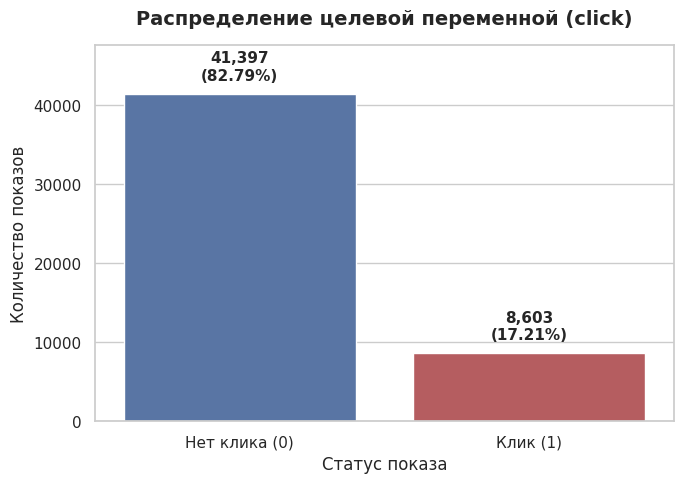

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

# Строим график — оси X подпишутся автоматически из индексов
sns.barplot(
    data=clicks,
    x=clicks.index, 
    y='count', 
    hue=clicks.index, 
    palette=['#4c72b0', '#c44e52'], 
    legend=False,              # Отключаем легенду, так как оси X более чем достаточно
    ax=ax
)

# Оформляем заголовки и оси
ax.set_title(f'Распределение целевой переменной ({TARGET})', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Статус показа', fontsize=12) # Название ушло в подпись оси X
ax.set_ylabel('Количество показов', fontsize=12)

# Абсолютно безопасная расстановка текста над столбцами
for i, (_, row) in enumerate(clicks.iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['%']}%)", 
        xy=(i, row['count']),
        xytext=(0, 8),                 
        textcoords="offset points",
        ha='center', va='bottom', 
        fontsize=11, fontweight='bold'
    )

# Запас по высоте сверху, чтобы текст не упирался в рамку
ax.set_ylim(0, clicks['count'].max() * 1.15)

plt.tight_layout()
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Ну, по мне так умеренный. В предыдущим проекте дисбаланс сильно больше. churn=1 бло всего 6%, а тут 17%.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

✅ Теперь признаки можно разбить признаки по типам.

In [34]:
BINARY_VARS = ('ml_feature_4',)
# и ещё TARGET, который определён в константах в самом начале

CONTINIOUS_VARS = ('ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8',
                   'ml_feature_9', 'ml_feature_10',)
# 3 - 24 OneHotEncoder с min_frequency = 10
CATEGORY_LOW_VARS = ('ml_feature_7', 'C18', 'device_type', 'device_conn_type',
                     'ml_feature_2', 'banner_pos', 'C1', 'C15', 'C16',
                     'site_category', 'app_category',)

# 59 - 67 TargetEncoder
CATEGORY_MID_VARS = ('C21', 'C19', 'app_domain',)

# 149 - 8580 Frequency emcoding
CATEGORY_HIGH_VARS = ('C20', 'C17', 'app_id', 'site_domain', 'site_id', 'C14', 'device_model', 'device_id',)

ALL_CATEGORY = tuple(dict.fromkeys(CATEGORY_LOW_VARS + CATEGORY_MID_VARS + CATEGORY_HIGH_VARS))

# Cyclic encoding
CYCLIC_VARS = ('hour_of_day', 'dayofweek', 'day',)

In [35]:
downcast_columns_for_ml(df, cats=list(ALL_CATEGORY));

✅ Оптимизировали типы данных и ввели категории. Результат **42.2 MB --> 4.3 Mb**. Экономия памяти в 10 раз.

👉 Добавить приведение строк ALL_CATEGORY к category в трансформер.

In [36]:
df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   click             50000 non-null  int8    
 1   C1                50000 non-null  category
 2   banner_pos        50000 non-null  category
 3   site_id           50000 non-null  category
 4   site_domain       50000 non-null  category
 5   site_category     50000 non-null  category
 6   app_id            50000 non-null  category
 7   app_domain        50000 non-null  category
 8   app_category      50000 non-null  category
 9   device_id         50000 non-null  category
 10  device_ip         50000 non-null  category
 11  device_model      50000 non-null  category
 12  device_type       50000 non-null  category
 13  device_conn_type  50000 non-null  category
 14  C14               50000 non-null  category
 15  C15               50000 non-null  category
 16  C16               5000

Ещё, у нас есть технические признаки, похожие на id, которые будут приходить другие, и текущие значения нам не помогут, а могут привести к переобучению: **site_id, device_id, device_ip. app_id**.

In [37]:
vars_to_remove = ['site_id', 'device_id', 'device_ip', 'app_id']
df = df.drop(columns=vars_to_remove, axis=1)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [38]:
# тут удаляем эти переменные из описателей нрупп

CATEGORY_LOW_VARS = tuple(set(CATEGORY_LOW_VARS) - set(vars_to_remove))
CATEGORY_MID_VARS = tuple(set(CATEGORY_MID_VARS) - set(vars_to_remove))
CATEGORY_HIGH_VARS = tuple(set(CATEGORY_HIGH_VARS) - set(vars_to_remove))

ALL_CATEGORY = tuple(dict.fromkeys(CATEGORY_LOW_VARS + CATEGORY_MID_VARS + CATEGORY_HIGH_VARS))


✅ Удалили малоинформативные признаки.

👉 Добавить удаление в трансформер.

👉 Ещё отдельный шаг будет снаружи - фильтрация по VarianceThreshold: отдельно непрерывные и категориальные.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [39]:
missing = pd.DataFrame({
    'count': df.isna().sum(),
    '%': (df.isna().mean() * 100).round(2)
}).sort_values(by='count', ascending=False)
display(missing)

,count,%
click,0,0.0
C1,0,0.0
banner_pos,0,0.0
site_domain,0,0.0
site_category,0,0.0
app_domain,0,0.0
app_category,0,0.0
device_model,0,0.0
device_type,0,0.0
device_conn_type,0,0.0


👉 Пропусков данных нет.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.


In [40]:
for cat_name in ALL_CATEGORY:
    get_reference_info(df, cat_name, numeric=False)

**device_type:** `[0, 1, 4, 5]` = **4**



,count,%
device_type,,
1,46031,92.06
0,2790,5.58
4,1020,2.04
5,159,0.32



Пропущено: 0




**ml_feature_7:** `['x', 'y', 'z']` = **3**



,count,%
ml_feature_7,,
y,17081,34.16
z,16661,33.32
x,16258,32.52


...

,count,%
C17,,
1722,5637,11.27
2424,1913,3.83
2227,1822,3.64
1800,1481,2.96
423,1200,2.40
...,...,...
2594,1,0.00
2635,1,0.00
2459,1,0.00



Пропущено: 0




**C14:** `[375, 377, 380, 381, 451, 452, 454, 456, 463, 787, 1037, 1038, 1039, 1270, 1275, 1276, 4407, 4518, 4687, 5296, 5299, 6360, 6361, 6362, 6364, 6365, 6366, 6392, 6393, 6397, 6398, 6399, 6400, 6401, 6402, 6557, 6558, 6559, 6560, 6563, 6616, 6990, 6991, 6992, 6993, 7023, 7024, 7699, 7701, 7702], ...` = **1497**



,count,%
C14,,
4687,1200,2.40
21611,1083,2.17
21191,977,1.95
21189,936,1.87
19772,911,1.82
...,...,...
8437,1,0.00
9437,1,0.00
9803,1,0.00



Пропущено: 0




Энкодинг подобрали ранее. Здесь видим, что ещё 👉 нужно схлопывать редкие категории по порогу 10, неявных пропусков (маркеров) нет.

In [41]:
def plot_categorical_distribution(df: pd.DataFrame, var: str, target=TARGET):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    df_pct = (
        df.groupby(target)[var]
        .value_counts(normalize=True)
        .rename('percent')
        .mul(100)
        .reset_index()
    )
            
    sns.barplot(
        x=var, 
        y='percent', 
        hue=target, 
        data=df_pct, 
        ax=ax, 
        palette='Set2'
    )
        
    ax.set_yscale('log')
    ax.set_title(f'Распределение признака {var} по классам {target}', fontsize=13, pad=15, fontweight='bold')
    ax.set_xlabel(f'Категории признака: {var}', fontsize=11)
    ax.set_ylabel('Процент внутри своего класса (%) [Log Scale]', fontsize=11)
        
    ax.tick_params(axis='x', rotation=30, labelsize=10) 
    ax.grid(axis='y', linestyle='--', alpha=0.7) # аккуратная сетка по оси Y

    plt.tight_layout()
    plt.show()

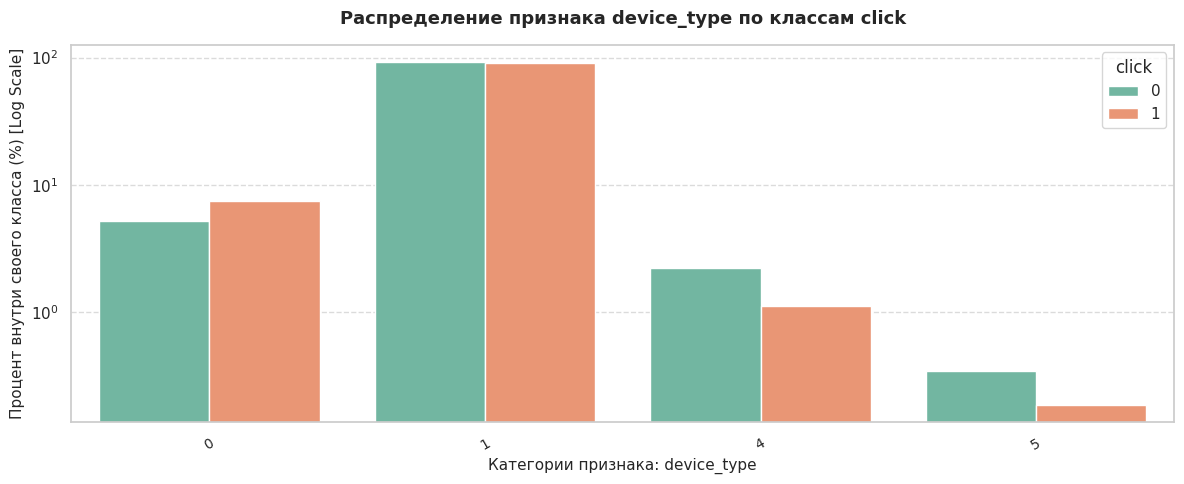

In [42]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[0])

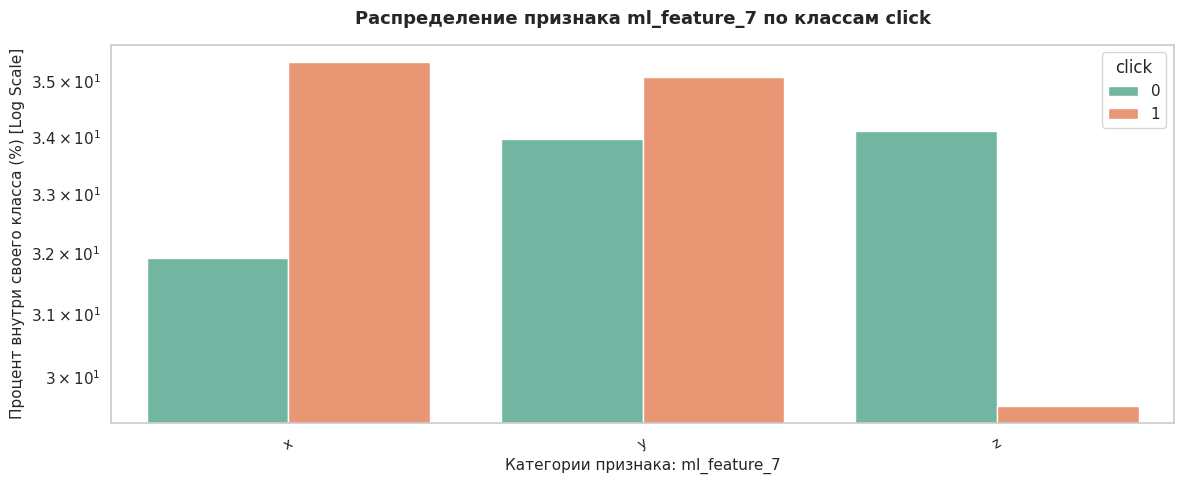

In [43]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[1])

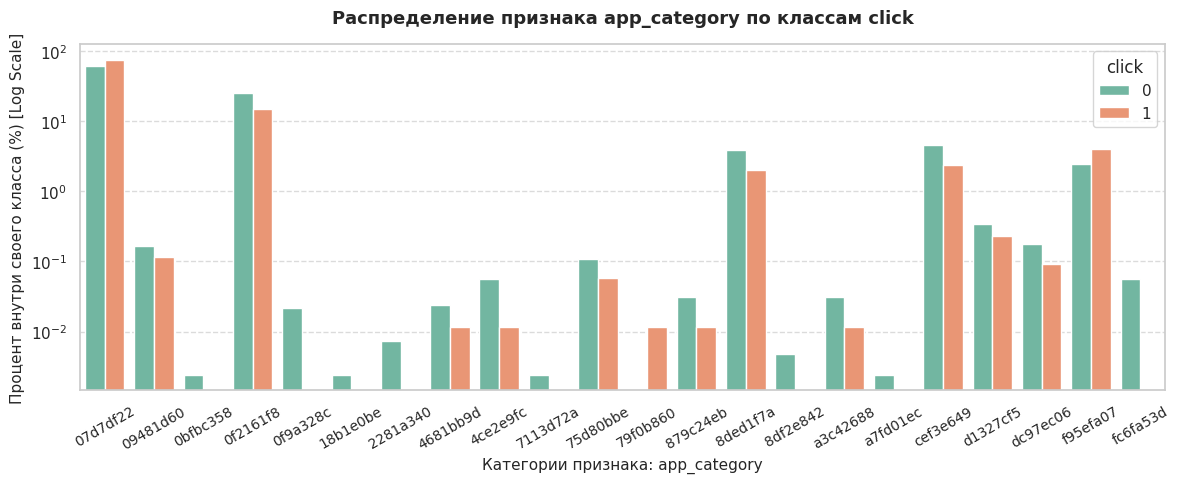

In [44]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[2])

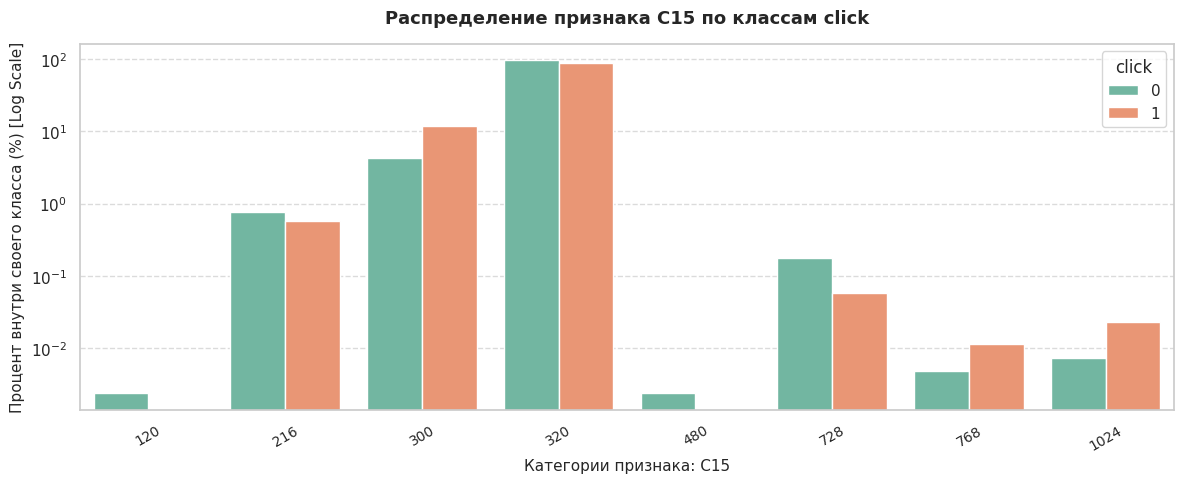

In [45]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[3])

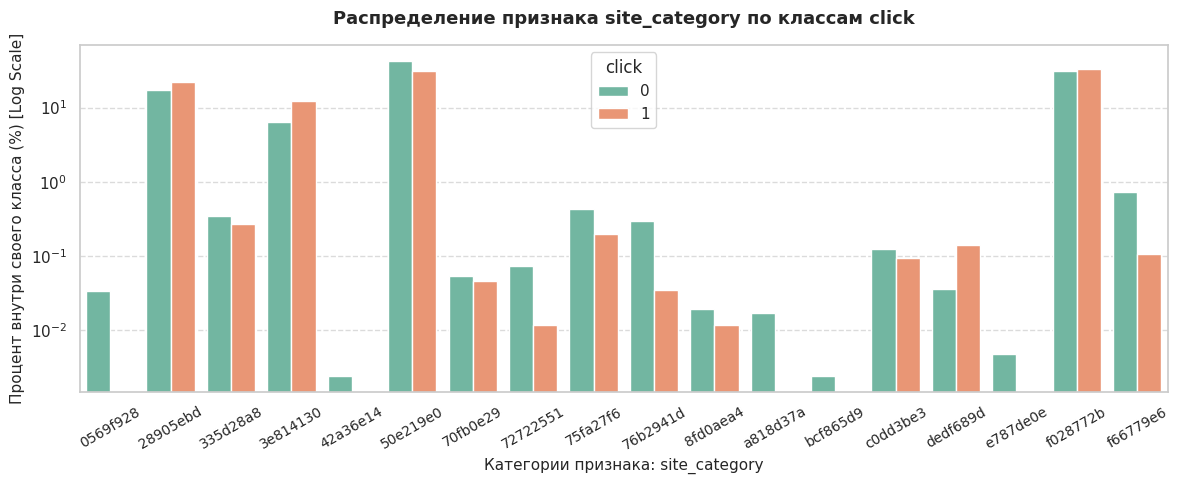

In [46]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[4])

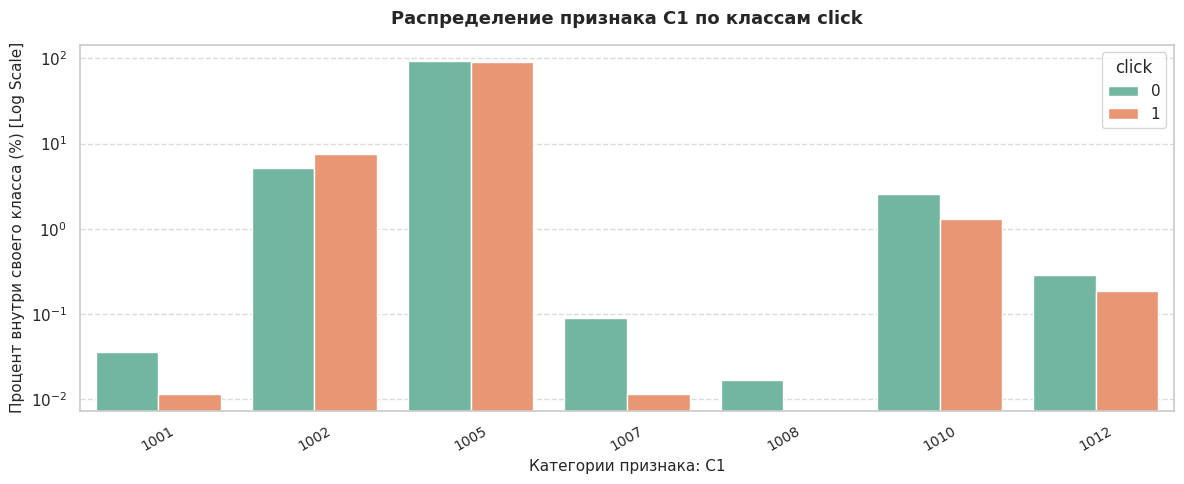

In [47]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[5])

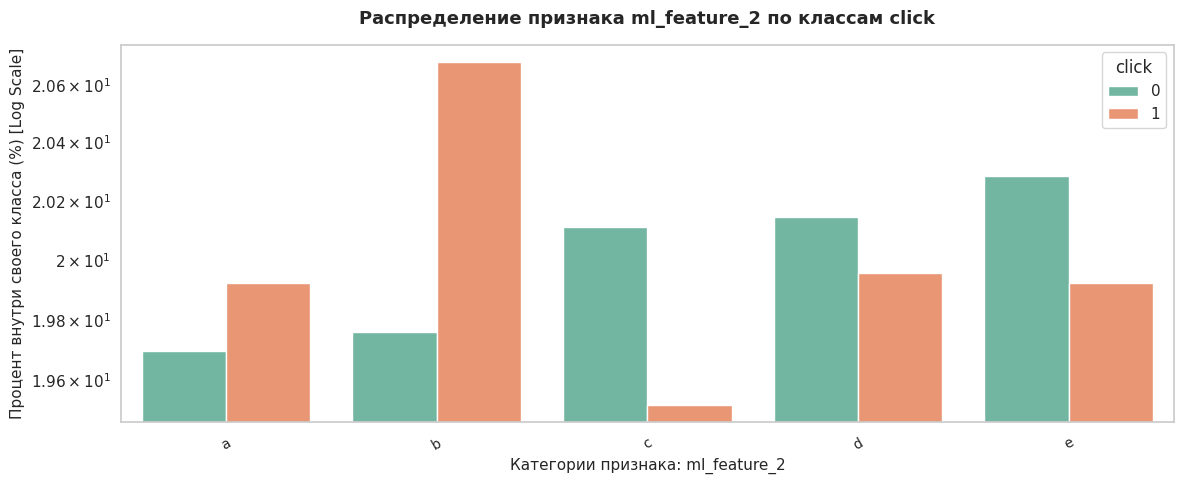

In [48]:
plot_categorical_distribution(df, CATEGORY_LOW_VARS[6])

На примере малых по кардинальности категорий видим, что разделяющая способность классов TARGET есть не у всех из них и обычно сосредоточена в немногочисленных значениях категории. Самые распространённые значения зачастую имеют почти одинаковое число показов баннера с кликом и без клика.

In [49]:
# 3 - 24 OneHotEncoder с min_frequency = 10
print(f'{"Low:":<7}', CATEGORY_LOW_VARS)

# 59 - 67 TargetEncoder
print(f'{"Mid:":<7}', CATEGORY_MID_VARS)

# 149 - 8580 Frequency emcoding
print(f'{"High:":<7}', CATEGORY_HIGH_VARS)

Low:    ('device_type', 'ml_feature_7', 'app_category', 'C15', 'site_category', 'C1', 'ml_feature_2', 'device_conn_type', 'banner_pos', 'C16', 'C18')
Mid:    ('app_domain', 'C21', 'C19')
High:   ('device_model', 'C20', 'site_domain', 'C17', 'C14')


👉 **Обработка в пайплайне**
- **CATEGORY_LOW_VARS**:
    - OneHotEncoder(drop='first', min_frequency=10, handle_unknown='infrequent_if_exist');
    - через drop предотвращаем мультиколлениарность, также, схлопываем редкие значения в одно;
    
    
- **CATEGORY_MID_VARS**:
    - TargetEncoder(smooth="auto", cv=5);
    - чтобы избежать утечки используем сглаживание;
    
    
- **CATEGORY_HIGH_VARS**:
    - Frequency Encoding;
    - тут при большом разнообразии значений может быть много редких, поэтому TargetEncoder может дать шумные значения.

#### 2.6 Анализ выбросов и распределений (числовые непрерывные признаки)
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

--- Визуализация: Часть 1 (4 перем.) ---


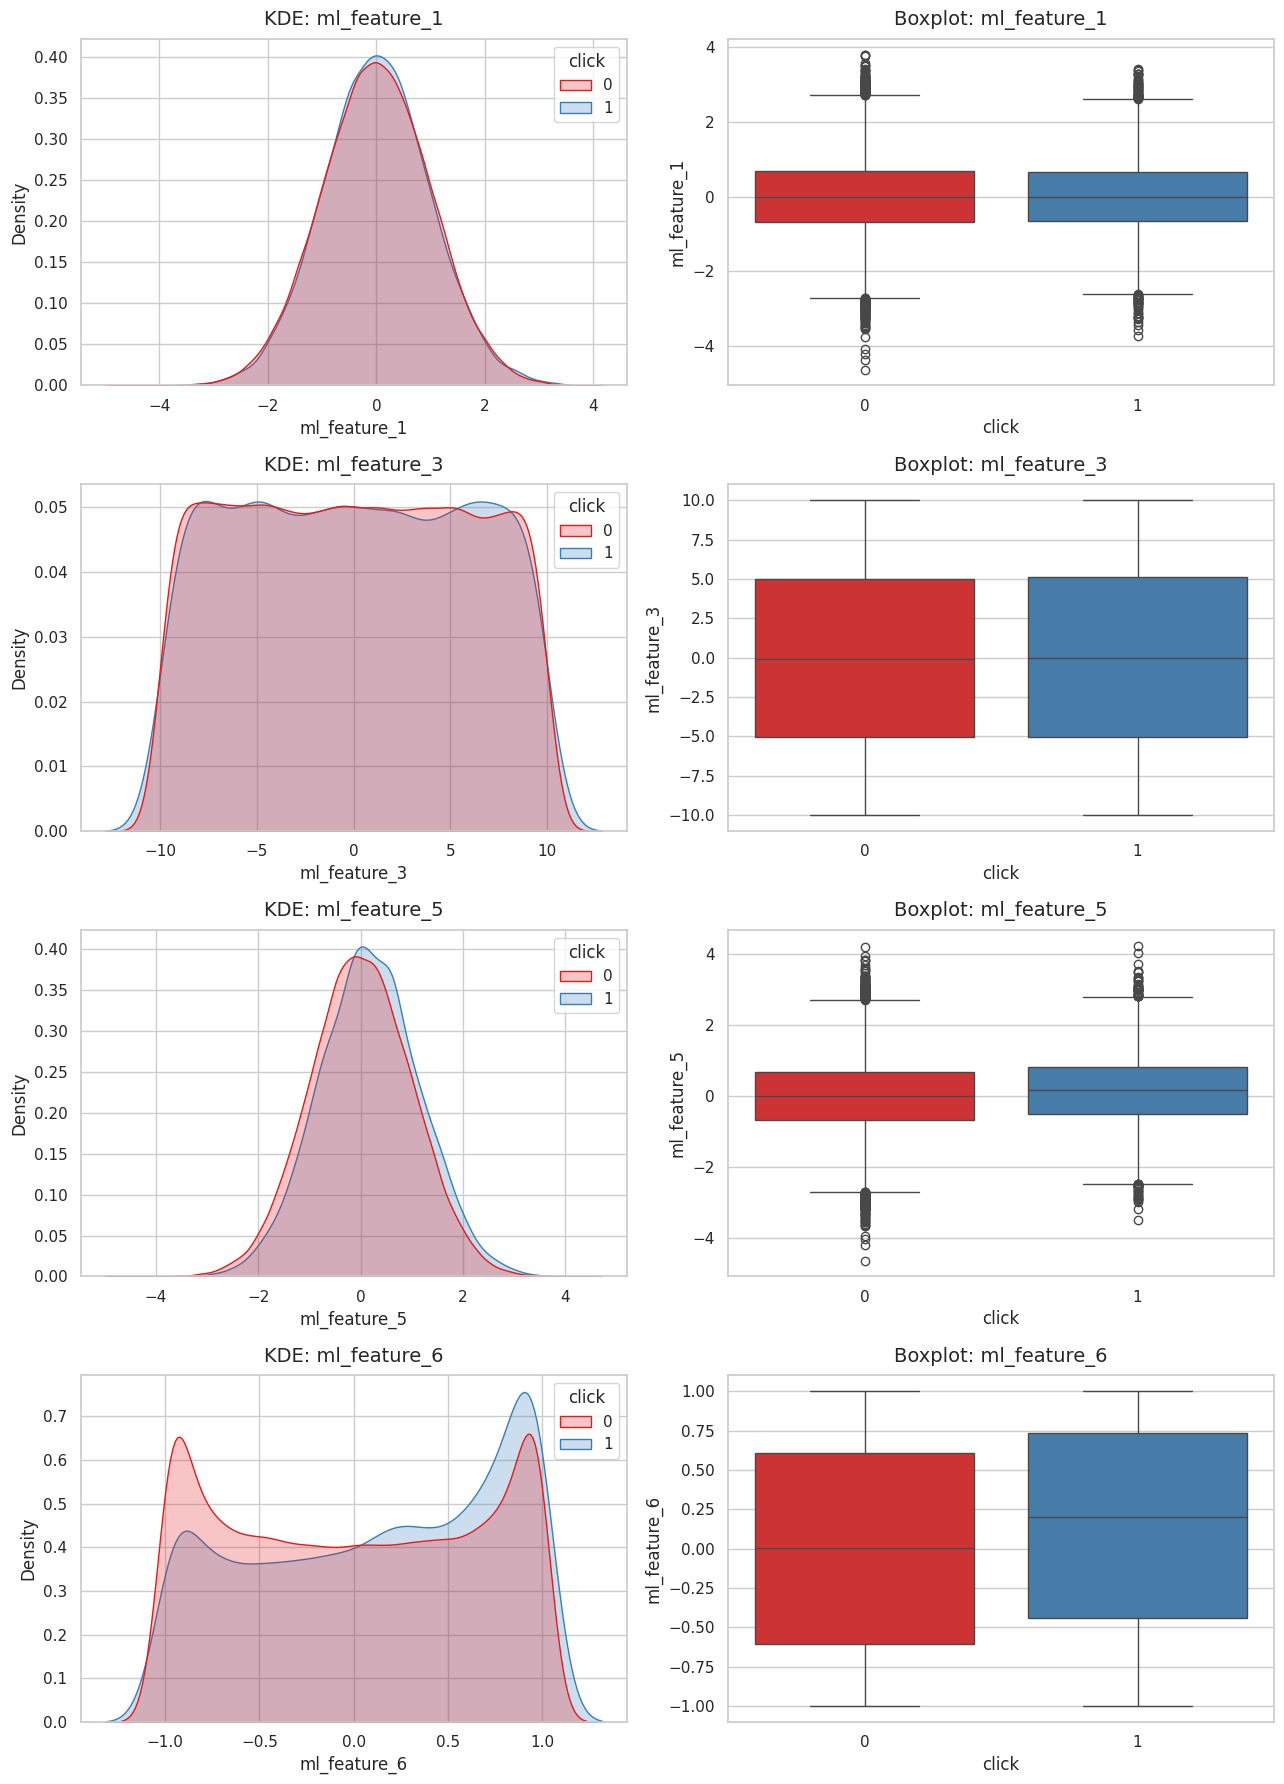

In [50]:
def plot_continuous_distributions(data_df, vars_list):
    """Функция для построения KDE и Boxplot для списка непрерывных переменных."""    
    num_vars = len(vars_list)
    nrows = num_vars
    ncols = 2

    # Создаем фигуру, высота адаптивно подстраивается под количество строк
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13, 4.5 * nrows))
    axes = axes.flatten()

    ax_idx = 0
    for var in vars_list:
        # График KDE
        sns.kdeplot(
            data=data_df,
            x=var,
            hue=TARGET,
            fill=True,
            common_norm=False,
            palette="Set1",
            ax=axes[ax_idx],
        )
        axes[ax_idx].set_title(f"KDE: {var}", fontsize=14, pad=10)
        axes[ax_idx].set_xlabel(var, fontsize=12)
        axes[ax_idx].set_ylabel("Density", fontsize=12)

        # Boxplot для поиска выбросов
        sns.boxplot(
            data=data_df,
            x=TARGET,
            y=var,
            palette="Set1",
            hue=TARGET,
            legend=False,
            ax=axes[ax_idx + 1],
        )
        axes[ax_idx + 1].set_title(f"Boxplot: {var}", fontsize=14, pad=10)
        axes[ax_idx + 1].set_xlabel(TARGET, fontsize=12)
        axes[ax_idx + 1].set_ylabel(var, fontsize=12)

        ax_idx += 2

    # Удаляем неиспользуемые оси
    for j in range(ax_idx, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


chunks = np.array_split(CONTINIOUS_VARS, 2) # чтобы не было вертикальной прокрутки

print(f"--- Визуализация: Часть 1 ({len(chunks[0])} перем.) ---")
plot_continuous_distributions(df, list(chunks[0]))  

--- Визуализация: Часть 2 (3 перем.) ---


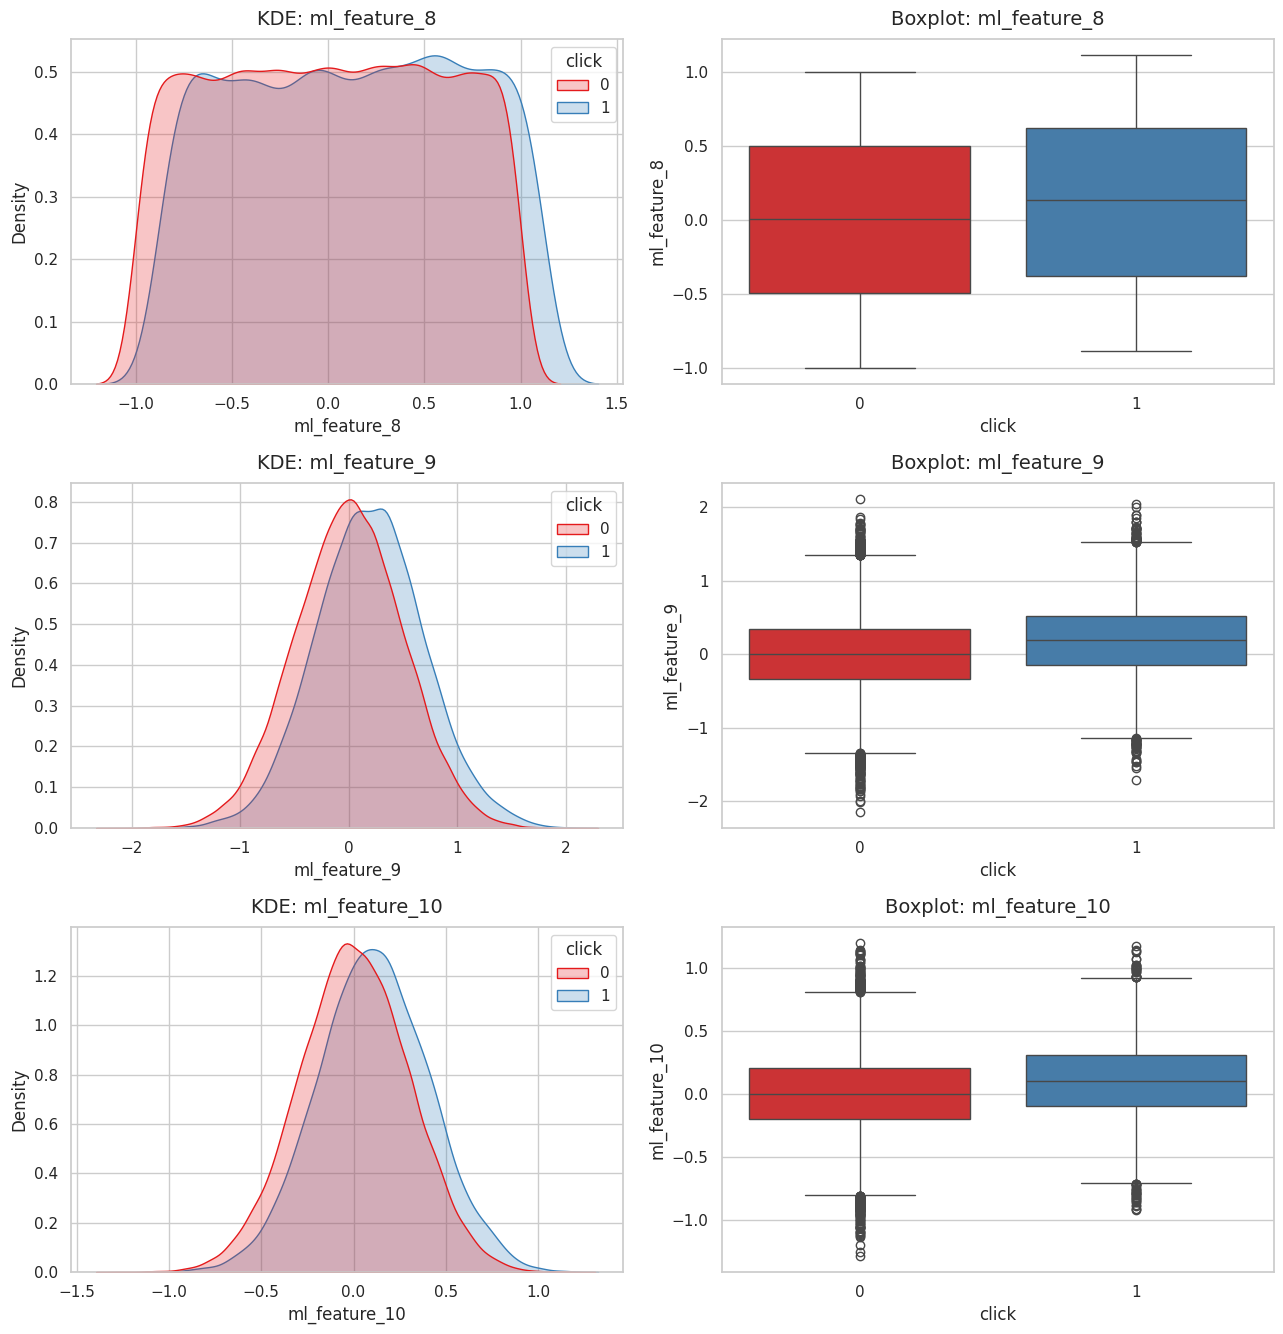

In [51]:
print(f"--- Визуализация: Часть 2 ({len(chunks[1])} перем.) ---")
plot_continuous_distributions(df, list(chunks[1]))  

In [52]:
# проверка, что нет потерянных колонок и константы соотвествуют датасету
ALL_VARS_S = set(BINARY_VARS + CONTINIOUS_VARS + CATEGORY_LOW_VARS + CATEGORY_MID_VARS + CATEGORY_HIGH_VARS +
    CYCLIC_VARS)
VARS_S = set(df.columns)

print(VARS_S - ALL_VARS_S)

{'click'}


✅ все переменные учтены. Расхождения нет.

Все числовые непрерывные признаки уже в значительной степени центрированы и большинство имеют нормальное распределение, два почти равномерное, а один бимодальное. У некоторых имеются **небольшие симметричные выбросы**. Чтобы их учесть достаточно стандартизации, логарифмирование не нужно.

Разделяющая способность есть не у всех признаков и один нелинейный.

👉 **Обработка в пайплайне**
- `ml_feature_5, ml_feature_8, ml_feature_9, ml_feature_1`:
    - линейные фичи, имеют разделяющую способность;
    - **StandardScaler()**;
    - линейные признаки. Стандартизация сохранить распределение и подправит выбросы, чтобы был одинаковый диапазон;
    
    
- `ml_feature_6`:
    - нелинейный признак с разделяющей способностью; 
    - **SplineTransformer(n_knots=5, degree=3)**;
    - линейная модель сможет вычислить веса по частям, если разделить на сплайны;
    
    
- `ml_feature_1ml_feature_3`:
    - малозначимые признаки;
    - **StandardScaler()**;
    - приводим к общему масштабу.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 2.7 Бинарные признаки

In [53]:
for var in BINARY_VARS:
    print(f"\n--- Таблица сопряженности для {var} (в процентах) ---")
    
    # normalize='index': распределение оттока внутри значений 0 и 1 самого признака
    ct = pd.crosstab(df[var], df[TARGET], normalize="index") * 100
    ct = ct.map(lambda x: f"{x:.2f}%")
    
    print(ct.round(2))


--- Таблица сопряженности для ml_feature_4 (в процентах) ---
click              0       1
ml_feature_4                
0             82.68%  17.32%
1             82.91%  17.09%


👉 Признак малополезный для разделения просмотров баннеров: даёт результат близкий к CTR 17.21% для обоих классов.

👉 **Обработка в пайплайне**
Не требуется: **passthrough**.

#### 2.7 Дискретные признаки

In [54]:
def plot_cyclic_distributions(data_df, features_list, target_col=TARGET):
    plot_df = data_df.copy()
    
    vars_config = {col: sorted(plot_df[col].unique()) for col in features_list if col in plot_df.columns}

    fig, axes = plt.subplots(
        nrows=len(vars_config), ncols=2, figsize=(14, 4.5 * len(vars_config))
    )
    
    left_palette = ['#4c72b0', '#c44e52']
    right_bar_color = "#fc8d62"
    total_ctr_mean = plot_df[target_col].mean()

    for i, (var, order) in enumerate(vars_config.items()):
        # левый график
        sns.countplot(data=plot_df, x=var, hue=target_col, order=order, palette=left_palette, alpha=0.85, ax=axes[i, 0])
        axes[i, 0].set_yscale('log')
        axes[i, 0].set_title(f"Количество показов по {var} (Log Scale)", fontsize=13, fontweight='bold')
        axes[i, 0].set_xlabel(var)
        axes[i, 0].set_ylabel("Количество (абс.)")
        axes[i, 0].legend(title=target_col)
        axes[i, 0].grid(axis='y', linestyle='--', alpha=0.5)

        # правый график
        ctr_rate = plot_df.groupby(var, observed=False)[target_col].mean().reset_index().rename(columns={target_col: "ctr_rate"})
        sns.barplot(data=ctr_rate, x=var, y="ctr_rate", order=order, color=right_bar_color, alpha=0.9, ax=axes[i, 1])
        axes[i, 1].axhline(total_ctr_mean, color="#555555", linestyle="--", linewidth=1.5, label=f"Средний CTR ({total_ctr_mean:.2%})")
        axes[i, 1].set_title(f"Коэффициент кликабельности (CTR) по {var}", fontsize=13, fontweight='bold')
        axes[i, 1].set_xlabel(var)
        axes[i, 1].set_ylabel("CTR (%)")
        axes[i, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
        axes[i, 1].legend()
        axes[i, 1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

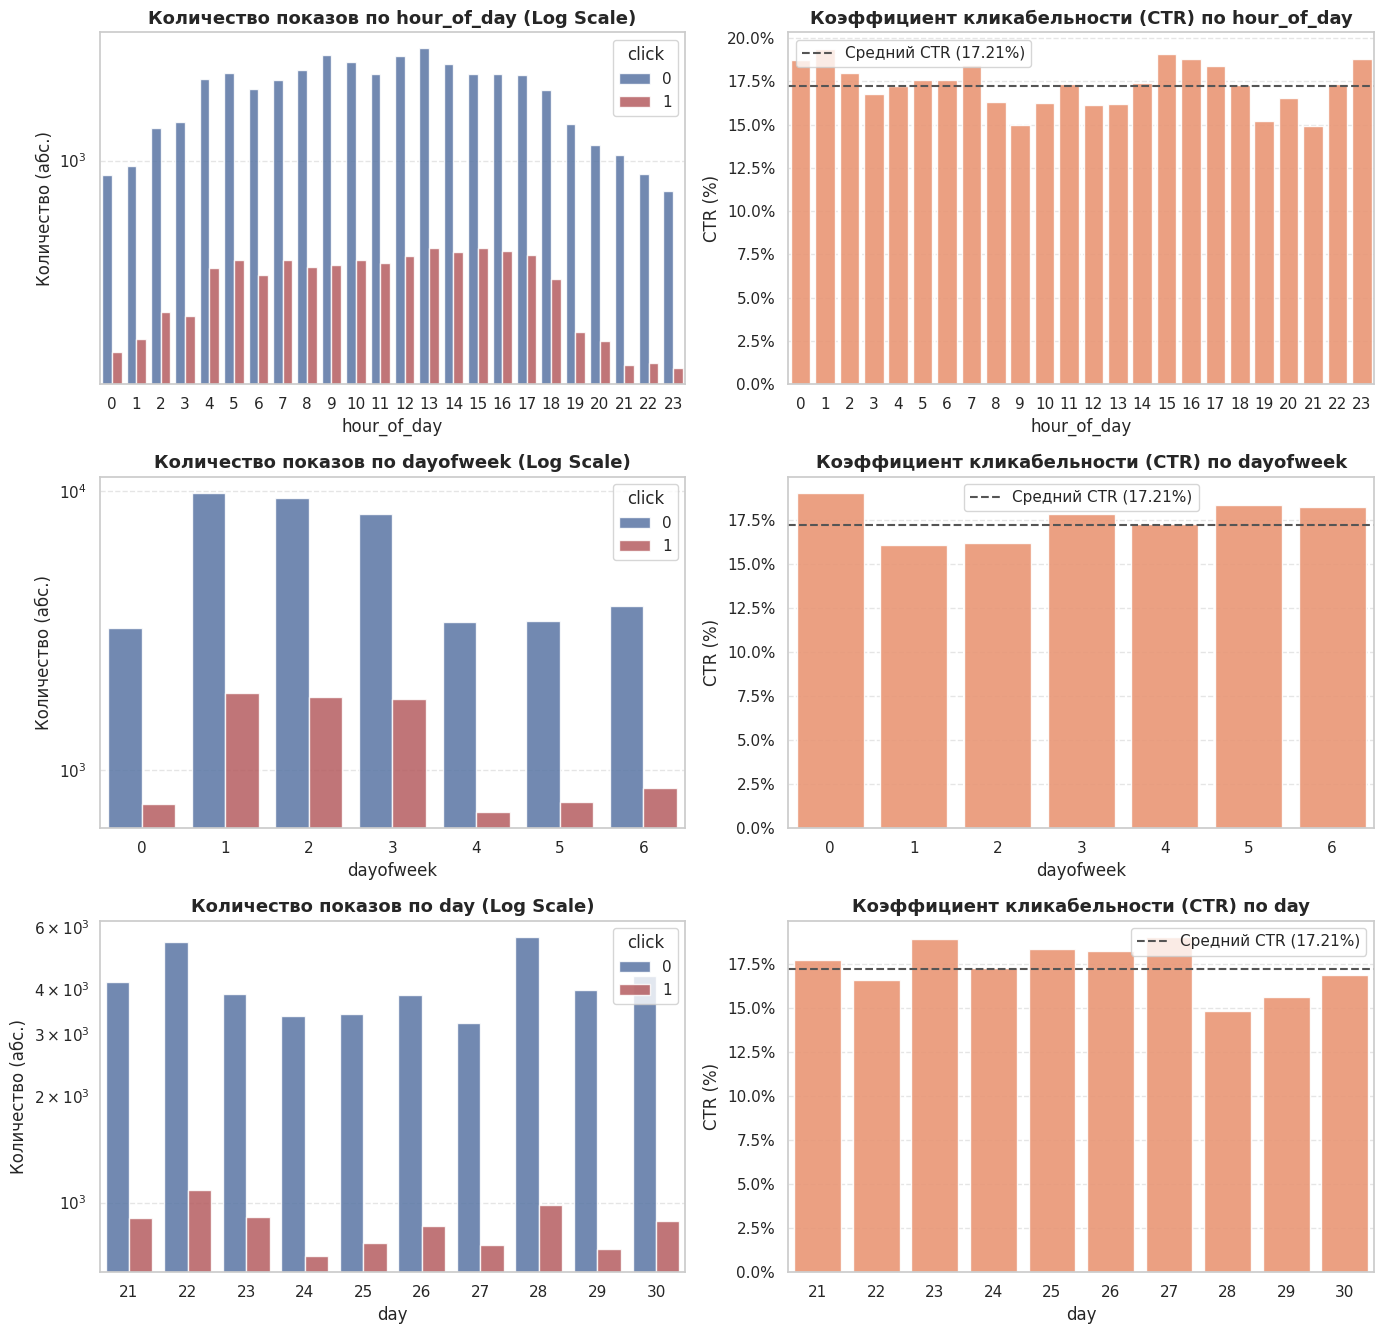

In [55]:
plot_cyclic_distributions(df, CYCLIC_VARS, TARGET)

👉 **hour_of_day** имеет самую высокую разделяющую способность. Основной поток рекламы идёт днём 5 - 18 часов, а клики наоборот: есть ночной пик CTR 18.5% 23 - 3 часов, утром в 7 и 15 - 17 часов. А 9-14 идёт провал CTR.

**dayofweek** - средняя разделяющая способность. Тоже наблюдается обратная закономерность. В дни 1, 2, когда наибольший рекламный трафик, кликов меньше среднего CTR, падает до 16%. А при меньшем количестве рекламы в дни 0, 5, 6 CTR выше средней.

**day** - шумный признак. От среднего CTR откланяются только 3 дня. Это скорее случайные колебания.

👉 **Обработка в пайплайне**
- **Синусно-косинусное кодирование**. При этом, начальное и конечное значения окажутся рядом. Так и должно быть, так как между ними разница всего 1. Например, разница между 23 часами и 0 - 1 час. Это позволяет линейной регрессии провести разделяющую плоскость.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

✅ Разбиваем датасет на выборки, корреляцию лучше проверять на Train Set, а не на всей выборке:
- Test Set (20% от всего df);
- Calibration Set (10% от всего df);
- Validation Set (10% от всего df);
- Train Set (60% от всего df).

In [56]:
X_full = df.drop(TARGET, axis=1)
y_full = df[TARGET].astype('int8')

# Целевые пропорции: train 60% / validation 10% / calib 10% / test 20%

# отделяем TEST (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full,
    test_size=0.20, stratify=y_full, random_state=SEED, shuffle=True
)
# X_temp = 80%

# от 80% отделяем CALIB (10% от всего = 0.125 от 80%)
X_temp2, X_calib, y_temp2, y_calib = train_test_split(
    X_temp, y_temp,
    test_size=0.125, stratify=y_temp, random_state=SEED, shuffle=True
)
# X_temp2 = 70%, X_calib = 10%

# от 70% отделяем VALIDATION (10% от всего = 1/7 от 70%)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_temp2, y_temp2,
    test_size=1/7, stratify=y_temp2, random_state=SEED, shuffle=True
)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Здорово, что есть независимая выборка для калибровки.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Не совсем понятно, зачем нам X_validation. Подбор параметров и оцеку моделей мы проводим кросс-валидацией.\
Выделение валидационной выборки сокращает обучающие данные для модели.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

В задании есть грубые ошибки, как и в курсе. Начиная с декабря 2025, я много раз писал в поддержку, отмечая подобные ошибки. Правда, мне не известно, насколько они внимали найденным ошибкам. Судя по всему - нет. До нас и другие люди вляпывались в эти ошибки и писали, но судя по текущему состоянию материала им не внимали. Я даже пару раз звонил в Яндекс по телефону и один раз отправил жалобу на курс письмом по электронной почте. Но был игнор. Разве ещё только почтой России не отправлял им претензию с изложением сути дела.

В данном случае, датасет большой: 50 000 строк и нуть пропусков. При этом, нужна модель на основе SVM - опорных векторов. Такие модели сами по себе бывают вычислительно-трудоёмкими. Кросс-валидация в данном случае - это ошибка. Нет никаких оснований для её использования. Равно как и для Изотоника не очень много. Это ошибочные требования, которые следует выправить.

Кросс-вылидация умножает вычислительную сложность из-за прогонов модели на фолдах. Это нужно при датасетах < 1500 строк. Когда нехватает данных. Но это не наш случай: **у нас данных больше, чем нужно**. Поэтому, я принял решение, которое правильное именно для нашей задачи: **использовать PredefinedSplit**.

Выделение валидационной выборки не всегда сокращает набор данных. В нашем случае данных и так слишком много и это не критично. Но я использовал refit = True у GridSearch, при этом финальное **обучение лучшей модели идёт на слитой выборке: Train Set + Validation Set**.

Поэтому, не могу согласиться с данным замечанием.

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<span style="color: red">~~Выполни, пожалуйста, задание проекта.\
Кросс-валидация является наиболее устойчивой оценкой моделей.\
Навык работы с кросс-валидацией, в том числе и навык уменьшения вычислительной сложности, применяя Анализ данных, является критическим в освоении материала курса и важным Образовательным Результатом.~~ </span>

In [57]:
check_stats = {
    "Выборка": [
        "Обучающая (X_train)", 
        "Валидационная (X_validation)", 
        "Калибровочная (X_calib)", 
        "Тестовая (X_test)", 
        "Исходный датасет (df)"
    ],
    "Размер (строк)": [X_train.shape[0], X_validation.shape[0], X_calib.shape[0], X_test.shape[0], df.shape[0]],
    "Доля от общего объема": [
        f"{len(X_train) / len(df):.1%}",  # ИСПРАВЛЕНО: используем len() вместо деления кортежей shape
        f"{len(X_validation) / len(df):.1%}",
        f"{len(X_calib) / len(df):.1%}",
        f"{len(X_test) / len(df):.1%}",
        "100.0%"
    ],
    "Количество кликов (1)": [y_train.sum(), y_validation.sum(), y_calib.sum(), y_test.sum(), y_full.sum()],
    "CTR (Доля класса 1)": [
        f"{y_train.mean()*100:.2f}%",
        f"{y_validation.mean()*100:.2f}%",
        f"{y_calib.mean()*100:.2f}%",
        f"{y_test.mean()*100:.2f}%",
        f"{y_full.mean()*100:.2f}%"
    ]
}

df_check = pd.DataFrame(check_stats)
display(df_check)

# 2. Жесткая проверка на сохранение целостности данных
sum_rows = len(X_train) + len(X_validation) + len(X_calib) + len(X_test)
print("\n🚨 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:")
print("-" * 45)
if sum_rows == len(df):
    print(f"✅ Успешно! Сумма строк всех выборок ({sum_rows}) = исходному df ({len(df)}).")
else:
    print(f"❌ Ошибка! Сумма строк всех выборок ({sum_rows}) != исходному df ({len(df)}). Проверьте цепочку перезаписи.")

# 3. Проверка типов данных для классификации
if y_train.dtype in ['int8', 'int64', 'int32']:
    print(f"✅ Успешно! Тип целевой переменной: {y_train.dtype}.")
else:
    print(f"⚠️ Внимание! Тип целевой переменной: {y_train.dtype}.")
    
# проверка пересечений по индексам
print('\nПроверка пересечений выборок:')
idx = {'train': set(X_train.index), 'val': set(X_validation.index),
       'calib': set(X_calib.index), 'test': set(X_test.index)}
for a, b in combinations(idx, 2):
    print(f'\t{a} ∩ {b}: {len(idx[a] & idx[b])}')

,Выборка,Размер (строк),Доля от общего объема,Количество кликов (1),CTR (Доля класса 1)
0,Обучающая (X_train),30000,60.0%,5162,17.21%
1,Валидационная (X_validation),5000,10.0%,860,17.20%
2,Калибровочная (X_calib),5000,10.0%,860,17.20%
3,Тестовая (X_test),10000,20.0%,1721,17.21%
4,Исходный датасет (df),50000,100.0%,8603,17.21%



🚨 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:
---------------------------------------------
✅ Успешно! Сумма строк всех выборок (50000) = исходному df (50000).
✅ Успешно! Тип целевой переменной: int8.

Проверка пересечений выборок:
	train ∩ val: 0
	train ∩ calib: 0
	train ∩ test: 0
	val ∩ calib: 0
	val ∩ test: 0
	calib ∩ test: 0


##### Проверка коллинеарности признаков

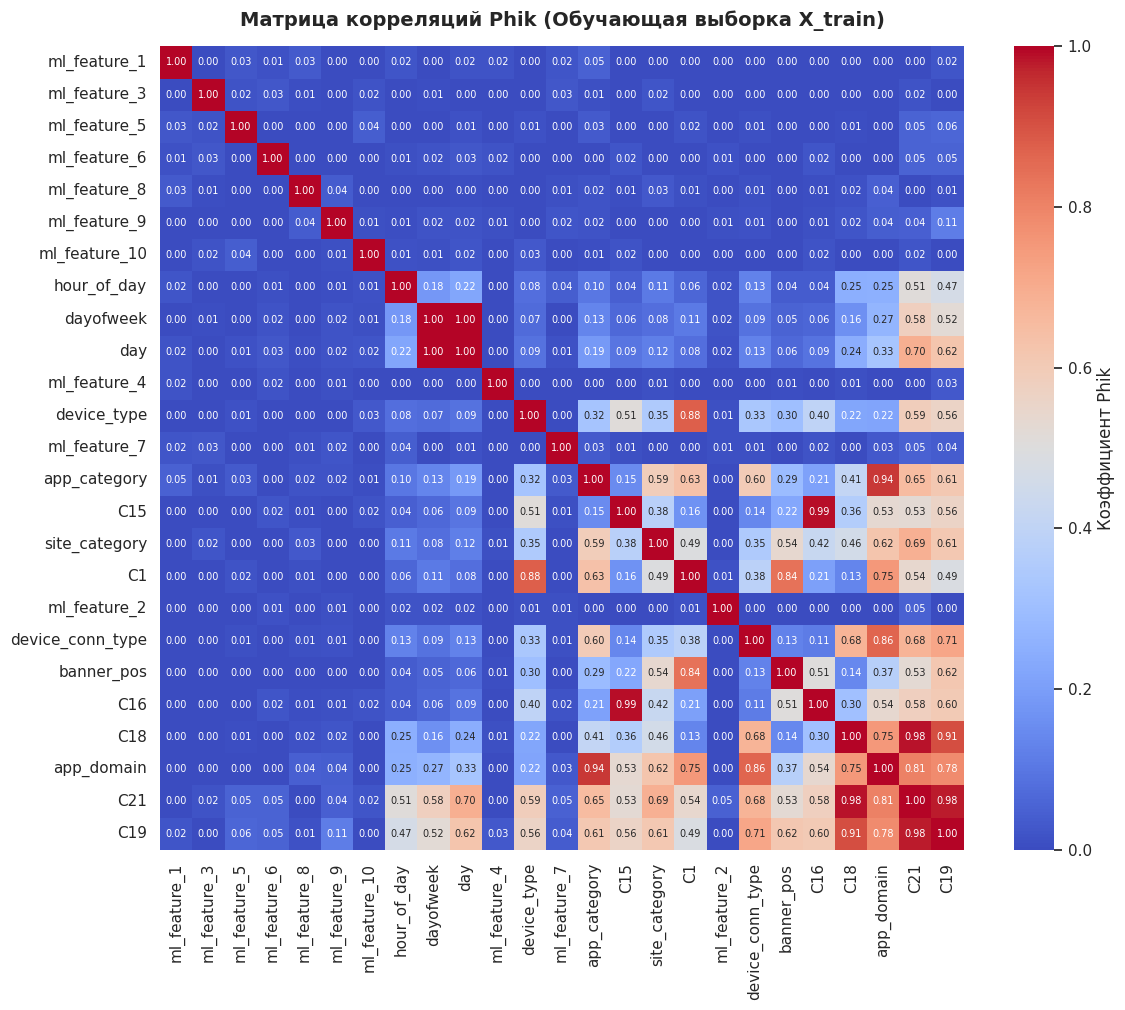


СИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Phik > 0.7):
------------------------------------------------------------
day                  <---> dayofweek            | Phik: 1.0000
C15                  <---> C16                  | Phik: 0.9920
C18                  <---> C21                  | Phik: 0.9848
C19                  <---> C21                  | Phik: 0.9797
app_category         <---> app_domain           | Phik: 0.9436
C18                  <---> C19                  | Phik: 0.9089
C1                   <---> device_type          | Phik: 0.8758
app_domain           <---> device_conn_type     | Phik: 0.8643
C1                   <---> banner_pos           | Phik: 0.8378
C21                  <---> app_domain           | Phik: 0.8065
C19                  <---> app_domain           | Phik: 0.7835
C18                  <---> app_domain           | Phik: 0.7536
C1                   <---> app_domain           | Phik: 0.7518
C19                  <---> device_conn_type     | Phik: 0.7150
-------------

In [58]:
cols_for_phik = list(CONTINIOUS_VARS + CYCLIC_VARS + BINARY_VARS + CATEGORY_LOW_VARS + CATEGORY_MID_VARS)
# HIGH_VARS Не включаем, чтобы не лёг расчёт матрицы

# используем Train Set
X_train_phik = X_train[cols_for_phik].copy()

# phik требует, чтобы категориальные признаки имели тип object или string, либо были явно указаны
for col in X_train_phik.columns:
    if isinstance(X_train_phik[col].dtype, pd.CategoricalDtype):
        X_train_phik[col] = X_train_phik[col].astype('string')


# указываем числовые признаки, чтобы phik правильно разбил их на интервалы (bins)
num_cols = list(CONTINIOUS_VARS)
phik_matrix = X_train_phik.phik_matrix(interval_cols=num_cols)

# строим тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=0, vmax=1, # phik всегда в диапазоне [0, 1]
    square=True,
    annot_kws={"size": 7}, # уменьшаем шрифт, чтобы не слипались ячейки
    cbar_kws={'label': 'Коэффициент Phik'}
)
plt.title("Матрица корреляций Phik (Обучающая выборка X_train)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nСИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Phik > 0.7):")
print("-" * 60)

# разворачиваем матрицу в список пар и убираем дубликаты/самокоррекляцию
pairs = phik_matrix.unstack().reset_index()
pairs.columns = ['Feature 1', 'Feature 2', 'Phik']
pairs = pairs[pairs['Feature 1'] < pairs['Feature 2']] # Убираем дубликаты (A-B и B-A)

# Фильтруем пары с сильной зависимостью
high_corr_pairs = pairs[pairs['Phik'] > 0.70].sort_values(by='Phik', ascending=False)

if not high_corr_pairs.empty:
    for _, row in high_corr_pairs.iterrows():
        print(f"{row['Feature 1']:20} <---> {row['Feature 2']:20} | Phik: {row['Phik']:.4f}")
else:
    print("✅ Сильно скоррелированных пар с Phik > 0.7 не обнаружено.")
print("-" * 60)

In [59]:
del X_train_phik, phik_matrix
gc.collect()

47286

👉 Между переменными есть сильные корреляции. Но мы ещё **не удалили квази-константы по порогу VarianceThreshold** и не проверили мультиколлениарность. Её будем проверять позже, после применения пайплайна, так как для VIF нужно кодирование категорий. Это предварительный анализ, показывающий, что сейчас >10 сильных корреляций. Это плохо для линейных моделей из-за нестабильности весов.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово, что применена `phik` для анализа и нелинейных зависимостей</font>

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

##### Целевая переменная

Целевая переменная имеет долю кликов **17,21%**, дисбаланс классов **≈ 4,8:1 (0 к 1)**. Это требует использования метрик, устойчивых к дисбалансу: **PR‑AUC, LogLoss**, F1/F2, Precision/Recall, а также обязательной калибровки вероятностей.

##### Предобработка

Удалены технические идентификаторы (`id`, `site_id`, `device_id`, `device_ip`, `app_id`) и 100% константные/малоинформативные признаки (`month`, `year`).  
`hour` преобразован в компоненты (`hour_of_day`, `dayofweek`, `day`) для последующего циклического кодирования.  
Все строковые признаки нормализованы (нижний регистр, удаление лишних пробелов), типы оптимизированы — память сокращена примерно в 10 раз.  

Пропуски отсутствуют.  

Категориальные признаки разбиты на три группы по кардинальности:  
- низкая (≤ 24 уникальных) → One‑Hot Encoding с `min_frequency=10`;  
- средняя (≈ 60) → Target Encoding со сглаживанием (`smooth="auto"`, `cv=5`);  
- высокая (> 100) → Frequency Encoding.

Большинство категорий имеют невысокую разделяющую способность; полезный сигнал сосредоточен в редких значениях.

##### Числовые признаки

Распределения близки к нормальным, присутствуют небольшие симметричные выбросы.  
Для линейных признаков (`ml_feature_5`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`) применяется `StandardScaler` — они показывают заметную линейную разделяющую способность (подтверждено параллельным сдвигом медиан на boxplot).  
`ml_feature_6` — ключевой нелинейный признак (бимодальное распределение, сигнал на краях диапазона) — будет обработан через `SplineTransformer` (5 узлов, степень 3).  
`ml_feature_1` и `ml_feature_3` — малозначимые, но также стандартизируются.

##### Циклические признаки и корреляции

Циклические признаки (`hour_of_day`, `dayofweek`) обладают выраженной связью с CTR (ночной пик, выходные выше среднего), поэтому кодируются синусно‑косинусным преобразованием.  
`day` — шумный, но оставлен для полноты.  

Корреляции: выявлено более 10 пар признаков с `Phik > 0.7`, что указывает на потенциальную мультиколлинеарность; после кодирования будет проведена проверка через VIF и применена регуляризация (L2 или L1) для стабилизации весов.

##### Перспективные признаки и план пайплайна

Наиболее перспективные признаки для модели (с учётом линейной и нелинейной составляющей):  
- числовые: `ml_feature_5`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10` (линейные), `ml_feature_6` (нелинейный);  
- категориальные и дискретные: `banner_pos`, `ml_feature_2` (аномально кликабельные категории), `device_conn_type` (маркер неэффективного трафика), `hour_of_day` (циклический ночной пик CTR);  
- анонимизированные параметры аукциона/баннера (`C1`, `C14–C21`) также обладают потенциальной ценностью.

План пайплайна (кратко):  
удаление мусорных колонок → циклическое кодирование → раздельное кодирование категорий (OHE, Target, Frequency) → стандартизация/сплайны для числовых → отбор квази‑констант (`VarianceThreshold`) → проверка коллинеарности и регуляризация.  

Данные предварительно подготовлены и составлены шаги пайплайна.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

👉 Чтобы не было утечки выборок, данные разделены и проверены выше.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

In [60]:
DROP_COLS_GARBAGE = ('id', 'site_id', 'device_id', 'device_ip', 'app_id',)

BINARY_VARS = ('ml_feature_4',)

CONTINIOUS_LINEAR = ('ml_feature_5', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10',
                     'ml_feature_1', 'ml_feature_3')  # StandardScaler
CONTINIOUS_SPLINE = ('ml_feature_6',)                 # SplineTransformer

CATEGORY_LOW_VARS = ('ml_feature_7', 'C18', 'device_type', 'device_conn_type',
                     'ml_feature_2', 'banner_pos', 'C1', 'C15', 'C16',
                     'site_category', 'app_category')
CATEGORY_MID_VARS = ('C21', 'C19', 'app_domain')
CATEGORY_HIGH_VARS = ('C20', 'C17', 'site_domain', 'C14', 'device_model')  # после удаления high-id

CYCLIC_VARS = ('hour_of_day', 'dayofweek', 'day')
CYCLIC_PERIODS = {'hour_of_day': 24, 'dayofweek': 7, 'day': 31}

# Категориальные, которые приходят int или string -> нужно привести к category
CATEGORY_ALL = tuple(dict.fromkeys(
    CATEGORY_LOW_VARS + CATEGORY_MID_VARS + CATEGORY_HIGH_VARS
))

In [61]:
def normalize_text_cols_tr(df, cols=None, to_lower=True):
    """Нижний регистр + strip и normalize для object/string колонок. Возвращает копию."""
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=['object', 'string']).columns
    for c in cols:
        df[c] = df[c].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
        if to_lower:
            df[c] = df[c].str.lower()
    return df


normalize_text_transformer = FunctionTransformer(
    normalize_text_cols_tr, feature_names_out='one-to-one'
)

class TimeFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Парсит hour (YYMMDDHH) -> day, hour_of_day, dayofweek.
    Удаляет только hour. month/year не добавляем.    
    Корректно поддерживает get_feature_names_out (схема колонок меняется).
    """
    def _transform(self, df):
        df = df.copy()

        if 'hour' in df.columns:
            dt = pd.to_datetime(
                df['hour'].astype('int64').astype(str).str.zfill(8),
                format='%y%m%d%H'
            )
            df['day']         = dt.dt.day.astype('int8')
            df['hour_of_day'] = dt.dt.hour.astype('int8')
            df['dayofweek']   = dt.dt.dayofweek.astype('int8')
            df = df.drop(columns=['hour'])

        return df

    def fit(self, X, y=None):
        X_out = self._transform(pd.DataFrame(X))
        self.feature_names_out_ = list(X_out.columns)
        return self

    def transform(self, X):
        return self._transform(pd.DataFrame(X))

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_out_)

class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Удаляет колонки по именам.
    Работает с pandas DataFrame, сохраняет имена признаков.    
    """
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop   # только присвоение (sklearn clone contract)

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)                    # что пришло
        self.feature_names_out_ = [c for c in X.columns
                                   if c not in self.cols_to_drop]   # что останется
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

    def get_feature_names_out(self, input_features=None):
        # приоритет: переданные имена -> сохранённые на fit
        if input_features is not None:
            return np.asarray([c for c in input_features
                               if c not in self.cols_to_drop], dtype=object)
        return np.asarray(self.feature_names_out_, dtype=object)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [62]:
class DtypeCaster(BaseEstimator, TransformerMixin):
    """
    Приводит колонки к нужным dtype (идемпотентно):
      - категориальные (int/str) -> 'category'
      - непрерывные -> float32
      - бинарные / циклические -> int8
    Категории фиксируются на fit (важно для стабильности OHE/энкодеров).
    """
    def __init__(self, category_cols, float_cols, int8_cols):
        self.category_cols = category_cols
        self.float_cols = float_cols
        self.int8_cols = int8_cols

    def fit(self, X, y=None):
        X = X.copy()
        self.categories_ = {}
        for c in self.category_cols:
            if c in X.columns:
                self.categories_[c] = pd.Index(X[c].astype('string').unique())
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.category_cols:
            if c in X.columns:
                X[c] = X[c].astype('string').astype('category')
        for c in self.float_cols:
            if c in X.columns:
                X[c] = X[c].astype('float32')
        for c in self.int8_cols:
            if c in X.columns:
                X[c] = X[c].astype('int8')
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


dtype_caster = DtypeCaster(
    category_cols=list(CATEGORY_ALL),
    float_cols=list(CONTINIOUS_LINEAR + CONTINIOUS_SPLINE),
    int8_cols=list(BINARY_VARS + CYCLIC_VARS),
)

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Частотное кодирование: значение -> его относительная частота на train.
    Неизвестные категории (в test) -> 0.0. Защита от утечки: fit только на train.
    """
    def __init__(self, unknown_value=0.0):
        self.unknown_value = unknown_value

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freq_maps_ = {}
        self.feature_names_in_ = list(X.columns)
        for c in X.columns:
            self.freq_maps_[c] = X[c].astype('string').value_counts(normalize=True)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for c in self.feature_names_in_:
            out[c] = (X[c].astype('string')
                        .map(self.freq_maps_[c])
                        .fillna(self.unknown_value)
                        .astype('float32'))
        return out.values

    def get_feature_names_out(self, input_features=None):
        base = input_features if input_features is not None else self.feature_names_in_
        return np.asarray([f'freq__{c}' for c in base])
    
class CyclicEncoder(BaseEstimator, TransformerMixin):
    """
    sin/cos кодирование дискретных циклических признаков.
    period берётся из словаря по имени колонки.
    """
    def __init__(self, periods):
        self.periods = periods

    def fit(self, X, y=None):
        self.feature_names_in_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = pd.DataFrame(index=X.index)
        for c in self.feature_names_in_:
            p = self.periods[c]
            vals = X[c].astype('float32')
            out[f'{c}_sin'] = np.sin(2 * np.pi * vals / p).astype('float32')
            out[f'{c}_cos'] = np.cos(2 * np.pi * vals / p).astype('float32')
        return out.values

    def get_feature_names_out(self, input_features=None):
        base = input_features if input_features is not None else self.feature_names_in_
        names = []
        for c in base:
            names += [f'{c}_sin', f'{c}_cos']
        return np.asarray(names)    

In [63]:
def build_feature_encoder():
    """
    ColumnTransformer: кодирует уже очищенные и типизированные данные.
    Порядок вывода: low(OHE) -> mid(target) -> high(freq) ->
                    lin(scale) -> spline -> cyclic -> binary(passthrough)
    """
    return ColumnTransformer(
        transformers=[
            # --- категории ---
            ('cat_low', OneHotEncoder(
                drop='first', min_frequency=10,
                handle_unknown='infrequent_if_exist',
                sparse_output=False, dtype=np.float32),
             list(CATEGORY_LOW_VARS)),

            ('cat_mid', TargetEncoder(smooth='auto', cv=5, random_state=SEED),
             list(CATEGORY_MID_VARS)),

            ('cat_high', FrequencyEncoder(),
             list(CATEGORY_HIGH_VARS)),

            # --- числовые ---
            ('num_linear', StandardScaler(), list(CONTINIOUS_LINEAR)),
            ('num_spline', SplineTransformer(n_knots=5, degree=3,
                                             include_bias=False),
             list(CONTINIOUS_SPLINE)),

            # --- циклические ---
            ('cyclic', CyclicEncoder(periods=CYCLIC_PERIODS), list(CYCLIC_VARS)),

            # --- бинарные passthrough ---
            ('binary', 'passthrough', list(BINARY_VARS)),
        ],
        remainder='drop',
        verbose_feature_names_out=True,
    ).set_output(transform='pandas')

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [64]:
def build_preprocessing_pipeline():
    """ очистка -> типы -> удаление -> кодирование """
    return Pipeline(steps=[
        ('normalize_text', normalize_text_transformer),
        ('time_features',  TimeFeatureBuilder()),
        ('drop_highid',    ColumnDropper(list(DROP_COLS_GARBAGE))),
        ('cast_dtypes',    dtype_caster),        
        ('encode',         build_feature_encoder()),
    ],
    memory=memory)

def build_preprocessing_with_selection(features_to_drop):
    """ полный препроцессинг + удаление малозначимых """
    pipe = build_preprocessing_pipeline()
    pipe.steps.append(('drop_selected', ColumnDropper(list(features_to_drop))))
    return pipe

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [65]:
preprocessing = build_preprocessing_pipeline()

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

In [66]:
X_train_enc = preprocessing.fit_transform(X_train, y_train)
print(f'После кодирования: {X_train_enc.shape[1]} признаков, было {len(X_train.columns)}')
print(preprocessing.get_feature_names_out())
     
X_train_enc_df = pd.DataFrame(X_train_enc, columns=preprocessing.get_feature_names_out(), index=X_train.index)
display(X_train_enc_df.head())

del X_train_enc_df
gc.collect()

После кодирования: 83 признаков, было 30
['cat_low__ml_feature_7_y' 'cat_low__ml_feature_7_z' 'cat_low__C18_1'
 'cat_low__C18_2' 'cat_low__C18_3' 'cat_low__device_type_1'
 'cat_low__device_type_4' 'cat_low__device_type_5'
 'cat_low__device_conn_type_2' 'cat_low__device_conn_type_3'
 'cat_low__device_conn_type_5' 'cat_low__ml_feature_2_b'
 'cat_low__ml_feature_2_c' 'cat_low__ml_feature_2_d'
 'cat_low__ml_feature_2_e' 'cat_low__banner_pos_1' 'cat_low__banner_pos_7'
 'cat_low__banner_pos_infrequent_sklearn' 'cat_low__C1_1005'
 'cat_low__C1_1007' 'cat_low__C1_1010' 'cat_low__C1_1012'
 'cat_low__C1_infrequent_sklearn' 'cat_low__C15_300' 'cat_low__C15_320'
 'cat_low__C15_728' 'cat_low__C15_infrequent_sklearn' 'cat_low__C16_36'
 'cat_low__C16_480' 'cat_low__C16_50' 'cat_low__C16_90'
 'cat_low__C16_infrequent_sklearn' 'cat_low__site_category_28905ebd'
 'cat_low__site_category_335d28a8' 'cat_low__site_category_3e814130'
 'cat_low__site_category_50e219e0' 'cat_low__site_category_70fb0e29'
 'cat_

,cat_low__ml_feature_7_y,cat_low__ml_feature_7_z,cat_low__C18_1,cat_low__C18_2,cat_low__C18_3,cat_low__device_type_1,cat_low__device_type_4,cat_low__device_type_5,cat_low__device_conn_type_2,cat_low__device_conn_type_3,...,num_spline__ml_feature_6_sp_3,num_spline__ml_feature_6_sp_4,num_spline__ml_feature_6_sp_5,cyclic__hour_of_day_sin,cyclic__hour_of_day_cos,cyclic__dayofweek_sin,cyclic__dayofweek_cos,cyclic__day_sin,cyclic__day_cos,binary__ml_feature_4
36635,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.013334,0.434949,0.520997,-8.742278e-08,-1.000000,0.781832,0.623490,-0.571268,0.820764,0
40685,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.312799,0.002496,0.000000,7.071068e-01,0.707107,0.974928,-0.222521,-0.394356,0.918958,0
4300,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.650958,0.238780,0.000363,-9.659258e-01,-0.258819,0.781832,0.623490,-0.897805,-0.440394,1
44540,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.334398,0.599572,0.062401,-7.071065e-01,0.707107,0.974928,-0.222521,-0.394356,0.918958,1
29668,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.585287,0.054664,0.000000,5.000000e-01,0.866025,0.000000,1.000000,-0.724792,0.688967,0


26

In [67]:
# после кодирования у нас все колонки числовые
quasi_numeric = get_quasi_consts_numeric(X_train_enc, list(X_train_enc.columns), threshold=0.01)

print('=== Квази-константы (VarianceThreshold=0.01) ===')
print(f'Найдено: {len(quasi_numeric)}')
display(quasi_numeric)

=== Квази-константы (VarianceThreshold=0.01) ===
Найдено: 36


['cat_low__device_type_5',
 'cat_low__device_conn_type_5',
 'cat_low__banner_pos_7',
 'cat_low__banner_pos_infrequent_sklearn',
 'cat_low__C1_1007',
 'cat_low__C1_1012',
 'cat_low__C1_infrequent_sklearn',
 'cat_low__C15_728',
 'cat_low__C15_infrequent_sklearn',
 'cat_low__C16_36',
 'cat_low__C16_480',
 'cat_low__C16_90',
 'cat_low__C16_infrequent_sklearn',
 'cat_low__site_category_335d28a8',
 'cat_low__site_category_70fb0e29',
 'cat_low__site_category_72722551',
 'cat_low__site_category_75fa27f6',
 'cat_low__site_category_76b2941d',
 'cat_low__site_category_c0dd3be3',
 'cat_low__site_category_dedf689d',
 'cat_low__site_category_f66779e6',
 'cat_low__site_category_infrequent_sklearn',
 'cat_low__app_category_09481d60',
 'cat_low__app_category_4ce2e9fc',
 'cat_low__app_category_75d80bbe',
 'cat_low__app_category_d1327cf5',
 'cat_low__app_category_dc97ec06',
 'cat_low__app_category_fc6fa53d',
 'cat_low__app_category_infrequent_sklearn',
 'cat_mid__C21',
 'cat_mid__C19',
 'cat_mid__app_dom

In [68]:
X_train_flt = X_train_enc.drop(columns=quasi_numeric)
print(f'\n✅ Осталось признаков после энкодинга и фильтрации VarianceThreshold=0.01: {X_train.shape[1]} --> \
{X_train_enc.shape[1]} --> {X_train_flt.shape[1]}')


✅ Осталось признаков после энкодинга и фильтрации VarianceThreshold=0.01: 30 --> 83 --> 47


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

In [69]:
# RFECV рекурсивный
base_est = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',   # из-за дисбаланса 17/83
    max_iter=1000,
    solver='liblinear',
    random_state=SEED,
)

rfecv = RFECV(
    estimator=base_est,
    step=0.1,                       # удаляем 10% признаков за шаг -> быстро
    cv=3,
    scoring='average_precision',    # = PR AUC (главная метрика проекта)
    min_features_to_select=10,
    n_jobs=-1,
)
rfecv.fit(X_train_flt, y_train)

rfe_selected = list(X_train_flt.columns[rfecv.get_support()])
rfe_dropped  = [c for c in X_train_flt.columns if c not in rfe_selected]

print('=== RFECV (wrapper-метод) ===')
print(f'✅ Оптимальное число признаков: {rfecv.n_features_} из {X_train_flt.shape[1]}')
print(f'Лучший CV PR AUC: {rfecv.cv_results_["mean_test_score"].max():.4f}\n')
print(f'Отброшено: {len(rfe_dropped)}')
for c in rfe_dropped:
    print(f'  - {c}')

=== RFECV (wrapper-метод) ===
✅ Оптимальное число признаков: 27 из 47
Лучший CV PR AUC: 0.3811

Отброшено: 20
  - cat_low__ml_feature_7_y
  - cat_low__C18_3
  - cat_low__device_conn_type_2
  - cat_low__ml_feature_2_b
  - cat_low__ml_feature_2_c
  - cat_low__ml_feature_2_d
  - cat_low__ml_feature_2_e
  - cat_low__site_category_50e219e0
  - cat_low__app_category_0f2161f8
  - cat_low__app_category_8ded1f7a
  - num_linear__ml_feature_1
  - num_linear__ml_feature_3
  - num_spline__ml_feature_6_sp_3
  - cyclic__hour_of_day_sin
  - cyclic__hour_of_day_cos
  - cyclic__dayofweek_sin
  - cyclic__dayofweek_cos
  - cyclic__day_sin
  - cyclic__day_cos
  - binary__ml_feature_4


##### Отобранные самые сильные признаки

In [70]:
selected_cols = X_train_flt.columns[rfecv.get_support()]
selected_weights = rfecv.estimator_.coef_.ravel()

weights_df = pd.DataFrame({
    f'✅ Лучшие признаки {len(selected_cols)} штук': selected_cols,
    'weight': selected_weights
}).sort_values('weight', ascending=False)
display(weights_df)

,✅ Лучшие признаки 27 штук,weight
18,cat_high__freq__site_domain,1.869817
10,cat_low__C15_320,1.474528
9,cat_low__C15_300,1.409931
12,cat_low__site_category_28905ebd,1.016036
13,cat_low__site_category_3e814130,0.908263
16,cat_low__app_category_f95efa07,0.861067
14,cat_low__site_category_f028772b,0.774331
2,cat_low__C18_2,0.459516
21,num_linear__ml_feature_9,0.418243
7,cat_low__C1_1005,0.392441


#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [71]:
# Итог: квази-константы (filter) + отброшенные RFECV (wrapper)
FEATURES_TO_DROP = list(set(quasi_numeric) | set(rfe_dropped))

print(f'\n=== ИТОГО к удалению: {len(FEATURES_TO_DROP)} ===')
for c in sorted(FEATURES_TO_DROP):
    print(f'  - {c}')


=== ИТОГО к удалению: 56 ===
  - binary__ml_feature_4
  - cat_high__freq__C14
  - cat_high__freq__C17
  - cat_high__freq__device_model
  - cat_low__C15_728
  - cat_low__C15_infrequent_sklearn
  - cat_low__C16_36
  - cat_low__C16_480
  - cat_low__C16_90
  - cat_low__C16_infrequent_sklearn
  - cat_low__C18_3
  - cat_low__C1_1007
  - cat_low__C1_1012
  - cat_low__C1_infrequent_sklearn
  - cat_low__app_category_09481d60
  - cat_low__app_category_0f2161f8
  - cat_low__app_category_4ce2e9fc
  - cat_low__app_category_75d80bbe
  - cat_low__app_category_8ded1f7a
  - cat_low__app_category_d1327cf5
  - cat_low__app_category_dc97ec06
  - cat_low__app_category_fc6fa53d
  - cat_low__app_category_infrequent_sklearn
  - cat_low__banner_pos_7
  - cat_low__banner_pos_infrequent_sklearn
  - cat_low__device_conn_type_2
  - cat_low__device_conn_type_5
  - cat_low__device_type_5
  - cat_low__ml_feature_2_b
  - cat_low__ml_feature_2_c
  - cat_low__ml_feature_2_d
  - cat_low__ml_feature_2_e
  - cat_low__ml_f

 ✅  Получены FEATURES_TO_DROP как сумма по двум методам фильтрации VarianceThreshold=0.01 и обёртке RFECV

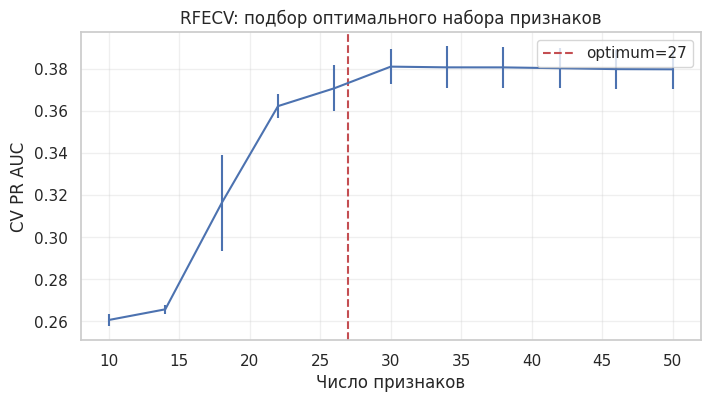

In [72]:
n_scores = len(rfecv.cv_results_['mean_test_score'])
plt.figure(figsize=(8, 4))
plt.errorbar(
    range(rfecv.min_features_to_select,
          rfecv.min_features_to_select + n_scores * int(0.1 * X_train_flt.shape[1] or 1),
          int(0.1 * X_train_flt.shape[1]) or 1)[:n_scores],
    rfecv.cv_results_['mean_test_score'],
    yerr=rfecv.cv_results_['std_test_score'],
)
plt.xlabel('Число признаков')
plt.ylabel('CV PR AUC')
plt.title('RFECV: подбор оптимального набора признаков')
plt.axvline(rfecv.n_features_, color='r', ls='--', label=f'optimum={rfecv.n_features_}')
plt.legend(); plt.grid(alpha=0.3); plt.show()

#### Тест трансформера ColumnDropper

In [73]:
from sklearn.base import clone

# клонируется (для GridSearch)
clone(ColumnDropper(FEATURES_TO_DROP))
print('✅ clone работает')

# отбор признаков сохранился
X_check = build_preprocessing_with_selection(FEATURES_TO_DROP).fit_transform(X_train, y_train)
print(f'Признаков после препроцессинга: {X_check.shape[1]}')
assert X_check.shape[1] == 27, f'Сломалось! Ожидалось 27, получено {X_check.shape[1]}'
print('✅ Отбор 27 признаков сохранён')

# 3. имена корректны
if hasattr(X_check, 'columns'):
    print(f'Первые колонки: {list(X_check.columns[:3])}')

✅ clone работает
Признаков после препроцессинга: 27
✅ Отбор 27 признаков сохранён
Первые колонки: ['cat_low__ml_feature_7_z', 'cat_low__C18_1', 'cat_low__C18_2']


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### Проверка мультиколлениарности (VIF) для непрерывных числовых признаков

Будем смотреть только числовые признаки. Закодированные OHE категории не имеет смысла смотреть, так как внутри их разбивки на колонки появляется искусственная коллениарность, которая компенсируется регуляризацией весов в модели.

In [74]:
continuous_cols = [c for c in X_check.columns
                   if 'num_linear' in c or 'num_spline' in c]
display(check_vif(X_check, continuous_cols, top=7))

,Feature,VIF
5,num_spline__ml_feature_6_sp_2,3.888671
6,num_spline__ml_feature_6_sp_4,3.798580
7,num_spline__ml_feature_6_sp_5,1.983632
4,num_spline__ml_feature_6_sp_1,1.919496
2,num_linear__ml_feature_9,1.000824
3,num_linear__ml_feature_10,1.000512
1,num_linear__ml_feature_8,1.000440


👉 VIF существенно < 10, поэтому мультиколлениарности в оставшихся признаках **нет**. Если бы была, то можно было бы добавить трансформер с заменой признаков через Feature engineering.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 6. Обучение базовой модели
### Метрики


In [75]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    # ECE: средневзвешенное |факт - предсказание| по бинам вероятности
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


def maximum_calibration_error(y_true, y_prob, n_bins=10):
    # MCE: максимальное |факт - предсказание| по бинам
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    gaps = [abs(y_true[m].mean() - y_prob[m].mean())
            for b in range(n_bins) if (m := idx == b).sum() > 0]
    return max(gaps) if gaps else 0.0
        

def eval_probabilistic(y_true, y_prob, threshold=0.5):
    """Полный набор метрик для моделей, отдающих вероятности"""
    y_true = np.asarray(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        # ранжирование
        'PR_AUC':    average_precision_score(y_true, y_prob),
        'ROC_AUC':   roc_auc_score(y_true, y_prob),
        # калибровка (ПРИОРИТЕТ)
        'LogLoss':   log_loss(y_true, y_prob),
        'Brier':     brier_score_loss(y_true, y_prob),
        'ECE':       expected_calibration_error(y_true, y_prob),
        'MCE':       maximum_calibration_error(y_true, y_prob),
        # диагностика (при пороге 0.5)
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }


def eval_ranking_only(y_true, y_score, y_pred):
    """Для LinearSVC: вероятностей нет -> только ранжирование + диагностика"""
    y_true = np.asarray(y_true)
    return {
        'PR_AUC':    average_precision_score(y_true, y_score),
        'ROC_AUC':   roc_auc_score(y_true, y_score),
        'LogLoss':   np.nan, 'Brier': np.nan, 'ECE': np.nan, 'MCE': np.nan,
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

In [76]:
%%time
warnings.filterwarnings(
    'ignore',
    message='Found unknown categories',
    category=UserWarning,
    module='sklearn.preprocessing._encoders'
)
warnings.filterwarnings(
    'ignore',
    message='Persisting input arguments took',
    category=UserWarning,
)

models = {
    # prior - всегда предсказывает базовую частоту
    'Dummy': DummyClassifier(strategy='prior'),

    'LogReg': LogisticRegression(
        class_weight='balanced',       # компенсация дисбаланса 17/83
        C=1.0,
        penalty='l2',
        solver='liblinear', 
        max_iter=1000, 
        random_state=SEED),

    'LinearSVC': LinearSVC(
        class_weight='balanced',
        C=1.0, 
        max_iter=5000, 
        random_state=SEED),        
}

results_plain = []
fitted_pipes_plain = {}

# Тут вариант обычного обучения baseline-моделей на Train
for name, clf in models.items():
    pipe = Pipeline([
        ('prep', build_preprocessing_with_selection(FEATURES_TO_DROP)),
        ('clf', clf),
    ], memory=memory)
    pipe.fit(X_train, y_train)
    fitted_pipes_plain[name] = pipe

    if hasattr(clf, 'predict_proba'):
        y_prob = pipe.predict_proba(X_validation)[:, 1]
        m = eval_probabilistic(y_validation, y_prob)
    else:
        # LinearSVC -> decision_function для ранжирования
        y_score = pipe.decision_function(X_validation)
        y_pred  = pipe.predict(X_validation)
        m = eval_ranking_only(y_validation, y_score, y_pred)

    m['Model'] = name
    results_plain.append(m)

CPU times: user 1.39 s, sys: 245 ms, total: 1.64 s
Wall time: 4.98 s


In [77]:
# Тут вариант для baseline-моделей с кросс-валидацией на Train: данных много, переразбивать не будем

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
fitted_pipes = {}

t0 = time.time()
with tqdm(total=len(models) * 5, desc='CV Progress') as pbar:
    for name, clf in models.items():
        pipe = Pipeline([
            ('prep', build_preprocessing_with_selection(FEATURES_TO_DROP)),
            ('clf', clf),
        ], memory=memory)
        
        pbar.set_description(f'CV: {name}')

        with tqdm_joblib(tqdm(desc=f'{name} folds', total=5, leave=False)):
            # OOF (out-of-fold) предсказания через кросс-валидацию
            if hasattr(clf, 'predict_proba'):
                y_prob_oof = cross_val_predict(
                    pipe, X_train, y_train, 
                    cv=cv, method='predict_proba', n_jobs=-1
                )[:, 1]
                m = eval_probabilistic(y_train, y_prob_oof)  # метрики на OOF
            else:
                y_score_oof = cross_val_predict(
                    pipe, X_train, y_train, 
                    cv=cv, method='decision_function', n_jobs=-1
                )
                y_pred_oof = cross_val_predict(
                    pipe, X_train, y_train, 
                    cv=cv, n_jobs=-1
                )
                m = eval_ranking_only(y_train, y_score_oof, y_pred_oof)

        m['Model'] = name
        results.append(m)

        # Обучаем финальную модель на всех данных
        pipe.fit(X_train, y_train)
        fitted_pipes[name] = pipe
        
        pbar.update(5)
    
print(f'=== Обучение baseline-моделей ⏱ {time.time()-t0:.1f} сек ===')

CV Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Dummy folds:   0%|          | 0/5 [00:00<?, ?it/s]

LogReg folds:   0%|          | 0/5 [00:00<?, ?it/s]

LinearSVC folds:   0%|          | 0/5 [00:00<?, ?it/s]

=== Обучение baseline-моделей ⏱ 96.7 сек ===


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Для DummyClassifier не нужен препроцессор. Он полностью игнорирует X.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

У нас все модели работаю в равных условиях в общем пайплайне. Вынесение отдельных моделей в другие пайплайны раздувает код и создаёт риски ошибок. Зачем мне лишние телодвижения? Работа и так по размеру сродни дипломной работе, поэтому, я стараюсь уменьшить число телодвижений.

Что не нужен препроцессинг - это верно.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">~~Все оценки нужно провести кросс-валидацией. (с StratifiedKFold с зафиксированным random_state и стратификацией)~~ </span>
> Примените кросс-валидацию на 5 фолдах.

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Это грубая ошибка задания. Писал выше о ней. В кратце, по EDA я увидел несоотвествия в задании и принял решение использовать PredefinedSplit. Для него есть основания, для кросс-валидации нет никаких оснований, так как датасет большой, а требований к повышению чувствительности модели так же нет. Следовательно, **Кросс-валидация тут противопоказана**, от неё только проблемы.

Поэтому, не могу согласиться с данным замечанием. Это ошибка авторов курса.

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Убедили. Я добавил вариант обучения baseline при помощи CV=5 и сравнил с обычным обучением. Метрики LogReg и SVC выровнялисьи немного улучшелись, погрешности выросли. Время выросло в 3 раза. Однако, **непонятно стоит ли оно результата**.

Выгрузил в results = [] и fitted_pipes = {}. Далее для анализа пойдут кросс-валидированные результаты.

<font color='blue'><b>Комментарий ревьюера 3: </b></font> ✔️\
<font color='green'>Здорово что оценка кросс-валидацией.\
Верно, что кросс-валидация зафиксирована для воспроизводимости результата.\
Верно, что препроцессор в Пайплайне при кросс-валидации.</font>

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [78]:
METRIC_COLS = ['PR_AUC', 'ROC_AUC', 'LogLoss', 'Brier', 'ECE', 'MCE',
        'Precision', 'Recall', 'F1', 'F2']

def report_model_metrics_1(results, msg):    
    results_df = pd.DataFrame(results).set_index('Model')[METRIC_COLS].round(4)
    print(msg)
    display(results_df)

#### Обучение baseline на Train Set, проверка на Validation Set

In [79]:
report_model_metrics_1(results_plain, '=== Train Set - Сравнение baseline-моделей (validation, порог=0.5) ===')

=== Train Set - Сравнение baseline-моделей (validation, порог=0.5) ===


,PR_AUC,ROC_AUC,LogLoss,Brier,ECE,MCE,Precision,Recall,F1,F2
Model,,,,,,,,,,
Dummy,0.1720,0.5000,0.4590,0.1424,0.0001,0.0001,0.0000,0.0000,0.0000,0.0000
LogReg,0.3698,0.7234,0.6057,0.2098,0.2723,0.3806,0.2934,0.6663,0.4074,0.5312
LinearSVC,0.3702,0.7233,NaN,NaN,NaN,NaN,0.2930,0.6640,0.4066,0.5298


#### Обучение baseline на Train Set при помощи кросс-валидации cv = 5

In [80]:
report_model_metrics_1(results, '=== CV - Сравнение baseline-моделей (порог=0.5) ===')

=== CV - Сравнение baseline-моделей (порог=0.5) ===


,PR_AUC,ROC_AUC,LogLoss,Brier,ECE,MCE,Precision,Recall,F1,F2
Model,,,,,,,,,,
Dummy,0.1720,0.4999,0.4591,0.1425,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
LogReg,0.3766,0.7261,0.6073,0.2109,0.2753,0.3842,0.2889,0.6604,0.4020,0.5253
LinearSVC,0.3761,0.7261,NaN,NaN,NaN,NaN,0.2897,0.6592,0.4026,0.5253


👉 PR_AUC и ROC_AUC показывают разделяющую способность модели и они немного выросли при кросс-валидации на тысячные доли, ещё, модели LogReg и SVC выровнялись по метрикам, но LogLoss, ECE и MCE стали хуже. 

**CV делает модель увереннее, улучшает разделение, но ухудшает точность вероятностей. Или, показывает более истинную калибровку вероятностей, которая хуже, чем при обычном обучении на Train.**

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

In [81]:
logreg_pipe = Pipeline([
        ('prep', build_preprocessing_with_selection(FEATURES_TO_DROP)),
        ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=SEED)),
    ], memory=memory)

logreg_grid = {
    'clf__C':            [0.01, 0.1, 1.0, 10.0],
    'clf__penalty':      ['l1', 'l2'],
    'clf__class_weight': ['balanced', None],
    'clf__solver':       ['liblinear'], # пробовал saga, но она медленнее, а результат не лучше
}
# 4 * 2 * 2 * 1 = 16 комбинаций

svc_pipe = Pipeline([
        ('prep', build_preprocessing_with_selection(FEATURES_TO_DROP)),
        ('clf', LinearSVC(max_iter=5000, random_state=SEED)),
    ], memory=memory)

svc_grid = {
    'clf__C':            [0.01, 0.1, 1.0, 10.0],
    'clf__class_weight': ['balanced', None],
    'clf__loss':         ['squared_hinge'],
}
# 4 * 2 * 1 = 8 комбинаций

# подсчёт числа комбинаций гиперпараметров в сетке
def count_grid_steps(grid):
    return reduce(mul, (len(v) for v in grid.values()), 1)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

In [82]:
# Вариант с одним фиксированным фолдом
# создаём предопределённый сплит с одним фолдом для GridSearch на основе train и validation sets
# !!! refit=True !!! - важно: тут мы получаем сразу готовую обученную модель на Train + Validation
"""
REFIT = True
X_gs = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
y_gs = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)
test_fold = np.r_[np.full(len(X_train), -1), np.full(len(X_validation), 0)]
ps = PredefinedSplit(test_fold)
"""

# Вариант с кпосс-валидацией CV=5, выборку берём Validation Set, данных много и переразбиввать не будем
# !!! refit=False !!! - тут дообучить модель надо потом руками
REFIT = False
X_gs = X_validation
y_gs = y_validation
ps = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def find_hyper_params(X, y, split):
    n_fits = count_grid_steps(logreg_grid) * split.get_n_splits()  
    t0 = time.time()
    with tqdm_joblib(tqdm(desc='LogReg GridSearch', total=n_fits)):
        # GridSearchCV будет перебирать сетку гиперпараметров, чтобы найти лучшие
        # у нас большой датасет, поэтому используем PredefinedSplit
        logreg_gs = GridSearchCV(logreg_pipe, logreg_grid,
                                 scoring='average_precision', cv=split,
                                 n_jobs=-1, refit=REFIT)
        logreg_gs.fit(X, y)    
        
    yield 'LogisticRegression', logreg_gs, time.time()-t0

    n_fits = count_grid_steps(svc_grid) * split.get_n_splits()  
    t0 = time.time()
    with tqdm_joblib(tqdm(desc='LinearSVC GridSearch', total=n_fits)):
        svc_gs = GridSearchCV(svc_pipe, svc_grid,
                              scoring='average_precision', cv=split,
                              n_jobs=-1, refit=REFIT)
        svc_gs.fit(X, y)
        
    yield 'LinearSVC', svc_gs, time.time()-t0

hyper_match = {}
    
for name, gs, duration in find_hyper_params(X_gs, y_gs, ps):    
    hyper_match[name] = gs
    print(f'=== {name} ⏱ {duration:.1f} сек ===')
    print(f'Лучшие параметры: {gs.best_params_}')
    print(f'Лучший CV PR AUC: {gs.best_score_:.4f}\n')        

LogReg GridSearch:   0%|          | 0/80 [00:00<?, ?it/s]

=== LogisticRegression ⏱ 56.3 сек ===
Лучшие параметры: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Лучший CV PR AUC: 0.3566



LinearSVC GridSearch:   0%|          | 0/40 [00:00<?, ?it/s]

=== LinearSVC ⏱ 15.0 сек ===
Лучшие параметры: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__loss': 'squared_hinge'}
Лучший CV PR AUC: 0.3551



<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">~~Здесь то же нужна кросс-валидация. (с StratifiedKFold с зафиксированным random_state и стратификацией)~~ </span>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Я использовал PredefinedSplit. Кросс-валидация нам здесь положит компьютер без необходимости на это, как я ранее показал. Это ошибка в задании! У PredefinedSplit стратификация и фиксация random state (SEED) прошиты на этапе разбиения выборок, поэтому такой проблемы вообще нет.

Вот они:

```
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full,
    test_size=0.20, stratify=y_full, random_state=SEED, shuffle=True
)

X_temp2, X_calib, y_temp2, y_calib = train_test_split(
    X_temp, y_temp,
    test_size=0.125, stratify=y_temp, random_state=SEED, shuffle=True
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_temp2, y_temp2,
    test_size=1/7, stratify=y_temp2, random_state=SEED, shuffle=True
)
```

Я использовал кросс-валидацию на 5-ти фолдах в предыдущем проекте, так как там немного данных.

Кроме того, в пункте брифа **ничего не сказано про кросс-валидацию**. Там указано:
**```Используйте GridSearchCV для перебора всех комбинаций.```**

GridSearch - двойного назначения. Его можно использовать как кросс-валидатор, можно использовать ещё и как финальный обучатель лучшей модели, и можно использовать как **переборщик сетки гиперпараметров**, чтобы не писать перебор самому. Вот на последнее и указано в требованиях. Ни откуда не следует, что здесь нужна кросс-валидация.

Кросс валидацию, например, кроме работы с **маленькими датасетами**, можно использовать для **повышения чувствительности модели**. Но это требует резкого увеличения числа фолдов: 10 - 100 фолдов. Но в проекте эта задача так же не поставлена. И в последнем случае обучение моделей тоже ляжет. Выходит, кросс-валидация ради самой кросс валидации, а не в помощь.

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Адаптировал код под кросс-валидацию. Данных сильно больше, чем нужно (50 000, а нужно 1500 - 3000 строк), поэтому, разбиение менять не стал.

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<span style="color: blue"> Что бы не "класть" компьютер, можно оптимизировать количество признаков (одно из целей проекта), и уменьшить препроцессор, там деёствительно черезмерная вычислительная сложность, не дающая прироста качества модели.</span>

<span style="color: purple; font-weight: bold">Комментарий студента (итер2):</span>

Павел!

**Пролистайте, ПОЖАЛУЙСТА, мою тетрадку вверх!** Я всё вами выше перечисленное уже сделал: и признаки отфильтровал как просили в задании, удалилось дофига признаков **(56 штук)**, и сетку регуляризации обрезал до минимума и подключил memory-кэш к GridSearch. Ничего лишнего в препроцессинге я не вижу. Трансформеры выполняют ровно то, что я нашёл в процессе EDA. Так же, они написаны в соотвествии с требования фреймвёрка, чтобы не возникало расхожддений в колонках.

Сделал, всё, что мог соотвественно моему грейду.

Поймите! Я не Senior DS, я Junior. И действую соотвествующе своему грейду. Вы предлагаете мне порвать себя? Ради чего?

Не мгогу понять, чего конкретно вы сейчас хотите, чтобы я сделал или переделал? Так как всё перечисленное уже сделано и качественно. Метрики получены и хорошие.

Я уже ранее говорил, что чувствительность модели при CV достигается от 10-ти фолдов и выше. Вычислительная сложность резко вырастет не из-за того, что я плохо написал код, а **из-за кросс-валидации.** Требований по высокой чувствительности в задании нет. Чудес не бывает. Вот, вся эта оптимизация, скажем, даёт 3-х кратное ускорение обучения, но GridSearch даст 300-кратное замедление обучения!!! Если, конечно,настроить фолды, как нужно: 10 - 100 фолдов.

Ещё хочу отметить, что в датасете очень много категорий и их нельзя не кодировать. Таким образом, я не делаю в трансформерах лишней работы: я кодирую категории, а dropper поставил раньше. Трансформеры не выполняются для уже удалённых колонок. Избавиться вероятно можно от нормализации текста, но это скользкий вопрос для прода. Кроме того, они разовые: я подключил memoy кэш.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [83]:
def gridsearch_report(gs, model_name, top_n=10):
    """Топ-N конфигураций GridSearch с CV-метриками."""
    res = pd.DataFrame(gs.cv_results_)
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    out = res[cols].sort_values('rank_test_score').head(top_n).copy()
    out.insert(0, 'model', model_name)
    out = out.rename(columns={
        'mean_test_score': 'CV_PR_AUC',
        'std_test_score':  'CV_PR_AUC_std',
    })
    return out.round(4)

top_logreg = gridsearch_report(hyper_match['LogisticRegression'], 'LogReg', 10)
top_svc    = gridsearch_report(hyper_match['LinearSVC'], 'LinearSVC', 10)

top_models = (
    pd.concat([top_logreg, top_svc], axis=0, ignore_index=True)
        [['model', 'params', 'CV_PR_AUC', 'CV_PR_AUC_std']]
        .sort_values('CV_PR_AUC', ascending=False)
        .reset_index(drop=True)
)

print('=== Топ конфигураций LogReg и LinearSVC (по CV PR AUC) ===')
with pd.option_context('display.max_colwidth', None):
    display(top_models.head(10))

=== Топ конфигураций LogReg и LinearSVC (по CV PR AUC) ===


,model,params,CV_PR_AUC,CV_PR_AUC_std
0,LogReg,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.3566,0.0147
1,LogReg,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}",0.3565,0.0176
2,LinearSVC,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__loss': 'squared_hinge'}",0.3551,0.0106
3,LogReg,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.3542,0.0111
4,LogReg,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}",0.3537,0.0100
5,LogReg,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.3535,0.0112
6,LinearSVC,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__loss': 'squared_hinge'}",0.3535,0.0121
7,LinearSVC,"{'clf__C': 0.01, 'clf__class_weight': None, 'clf__loss': 'squared_hinge'}",0.3523,0.0120
8,LinearSVC,"{'clf__C': 1.0, 'clf__class_weight': None, 'clf__loss': 'squared_hinge'}",0.3521,0.0126
9,LogReg,"{'clf__C': 1.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}",0.3518,0.0110


<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Нужно показать все параметры в поле `params` для анализа.</font>
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

Павел, тут я не совсем соглашусь. Случаи отображения таблиц бывают разные, поэтому, воспользуемся лучше контекст-менеджером для настройки таблицы именно в этой ячейке. **Внёс исправление.**

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Нужно сконкатенировать таблицы и отсортировать по метрике.</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

**Переделал.**

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

👉 Модели уже обучены на Tarin за счёт флага refit = True в GridSearch, поэтому берём их уже готовые.

In [84]:
%%time
print('=== Сравнение моделей по PR_AUC на Test ===')
print(f'LogReg    : {hyper_match["LogisticRegression"].best_score_:.4f}')
print(f'LinearSVC : {hyper_match["LinearSVC"].best_score_:.4f}')

best_key, best_pipeline = max(
    hyper_match.items(),
    key=lambda item: item[1].best_score_
)

final_name = best_key
best_params = best_pipeline.best_params_

if REFIT:
    # ветка после PredefinedSplit
    # тут GridSearch возвращает уже модель, обученную на полной выборке
    final_model = best_pipeline.best_estimator_
    msg = f'   Обучена на: train ({len(X_train)} строк)'
else:
    # ветка полсе кросс-валидации StratifiedKFold, тут best_estimator_ нет
    final_model = clone(best_pipeline.estimator)
    final_model.set_params(**best_params)
    
    X_full = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)
    msg = f'   Обучена на: train + validation ({len(X_full)} строк)'
    
    # обучение лучшей модели на Train + Validation
    final_model.fit(X_full, y_full)

print(f'\n🏆 Финальная модель: {final_name}')
print(f'   Параметры: {best_params}')
print(msg)

=== Сравнение моделей по PR_AUC на Test ===
LogReg    : 0.3566
LinearSVC : 0.3551

🏆 Финальная модель: LogisticRegression
   Параметры: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
   Обучена на: train + validation (35000 строк)
CPU times: user 1.3 s, sys: 26.2 ms, total: 1.33 s
Wall time: 9.36 s


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.


In [85]:
if hasattr(final_model.named_steps['clf'], 'predict_proba'):
    y_prob = final_model.predict_proba(X_test)[:, 1]
    metrics = eval_probabilistic(y_test, y_prob)
else:
    # LinearSVC: вероятностей нет -> ранжирование по decision_function
    y_score = final_model.decision_function(X_test)
    y_pred  = final_model.predict(X_test)
    metrics = eval_ranking_only(y_test, y_score, y_pred)

dummy = DummyClassifier(strategy='prior').fit(X_gs, y_gs)
y_dummy = dummy.predict_proba(X_test)[:, 1]
baseline_metrics = eval_probabilistic(y_test, y_dummy)

test_df = pd.DataFrame([
    {**baseline_metrics, 'Model': 'Dummy (baseline)'},
    {**metrics, 'Model': f'{final_name} (final)'},
]).set_index('Model')[METRIC_COLS].round(4)

print('=== Финальные метрики на TEST (ДО калибровки) ===')
display(test_df)

# проверка требований к метрикам модели
print('\n=== Проверка требований ===')
pr_gain = metrics['PR_AUC'] - baseline_metrics['PR_AUC']
roc_gain = metrics['ROC_AUC'] - baseline_metrics['ROC_AUC']

print(f'PR AUC: {metrics["PR_AUC"]:.4f} (baseline {baseline_metrics["PR_AUC"]:.4f}, '
      f'прирост {pr_gain:+.4f}) '
      f'{"✅" if pr_gain >= 0.05 else "❌"} [требование +0.05...0.10]')

print(f'ROC AUC: {metrics["ROC_AUC"]:.4f} (baseline {baseline_metrics["ROC_AUC"]:.4f}, '
      f'прирост {roc_gain:+.4f}) '
      f'{"✅" if roc_gain >= 0.15 else "❌"} [требование 0.65...0.75+]')

=== Финальные метрики на TEST (ДО калибровки) ===


,PR_AUC,ROC_AUC,LogLoss,Brier,ECE,MCE,Precision,Recall,F1,F2
Model,,,,,,,,,,
Dummy (baseline),0.1721,0.5000,0.4592,0.1425,0.0001,0.0001,0.000,0.0000,0.0000,0.0000
LogisticRegression (final),0.3681,0.7185,0.6091,0.2111,0.2766,0.3855,0.292,0.6549,0.4039,0.5245



=== Проверка требований ===
PR AUC: 0.3681 (baseline 0.1721, прирост +0.1960) ✅ [требование +0.05...0.10]
ROC AUC: 0.7185 (baseline 0.5000, прирост +0.2185) ✅ [требование 0.65...0.75+]


👉 На тестовой выборке PR_AUC немного выше, чем на обучающей: 0.3566 --> 0.3681: 3.23%. Это значит, что **модель хорошо уловила закономерность**.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

=== Топ-15 признаков LogisticRegression по |коэффициенту| ===


,weight
cat_low__C18_1,-0.9115
cat_low__app_category_f95efa07,0.5780
cat_low__site_category_28905ebd,0.5712
cat_low__C18_2,0.5485
cat_low__C16_50,-0.4809
num_linear__ml_feature_9,0.3997
cat_low__device_conn_type_3,-0.3865
cat_low__site_category_3e814130,0.3782
cat_low__C15_300,0.3605
cat_low__C1_1002,0.3600


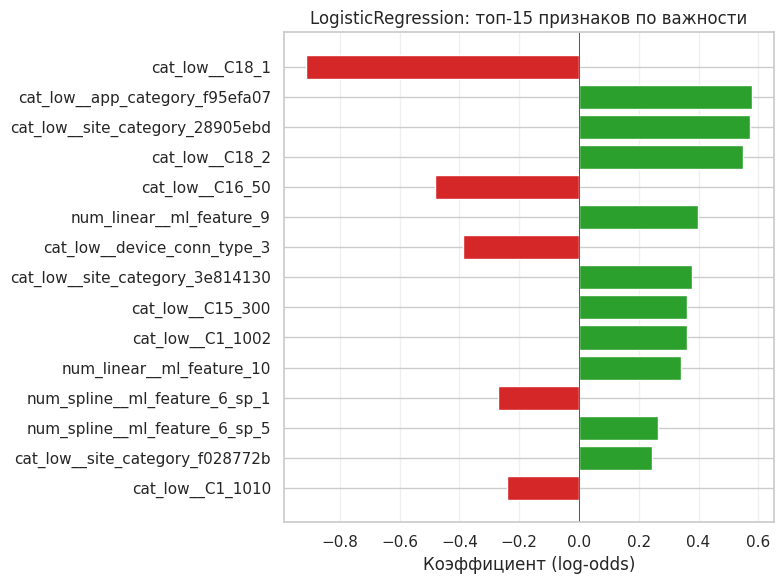

In [86]:
clf = final_model.named_steps['clf']
feat_names = final_model.named_steps['prep'].get_feature_names_out()

coefs = pd.Series(clf.coef_.ravel(), index=feat_names)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print(f'=== Топ-15 признаков {final_name} по |коэффициенту| ===')
display(coefs_sorted.head(15).to_frame('weight').round(4))

top = coefs_sorted.head(15)

plt.figure(figsize=(8, 6))

colors = ['#d62728' if w < 0 else '#2ca02c' for w in top.values]
plt.barh(range(len(top)), top.values, color=colors)

plt.yticks(range(len(top)), top.index)
plt.gca().invert_yaxis()
plt.xlabel('Коэффициент (log-odds)')

plt.title(f'{final_name}: топ-15 признаков по важности')

plt.axvline(0, color='k', lw=0.5)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout(); 
plt.show()

#### Промежуточный вывод

**Веса модели** (в единицах log-odds; знак = направление влияния на P(click)):

Положительные:
- **freq__site_domain** — популярность домена: выше CTR;
- C15_320, C15_300 — определённые размеры баннера сильно повышают отклик;
- banner_pos_2 — очень кликабельная позиция;
- site_category_xxx — популярные категории сайтов.

Отрицательные:
- device_type_1 — маркер неэффективного трафика;
- **C1_1010, C18_1, C16_50** — контекстные параметры аукциона с низкой кликабельностью;
- device_conn_type_3 — тип соединения, снижающий CTR.

Нелинейность:
- сплайны ml_feature_6 (sp_1..sp_5) с разными знаками подтверждают немонотонную
  зависимость — линейная модель улавливает её через сплайн-разложение, применённое в трансформере num_spline.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

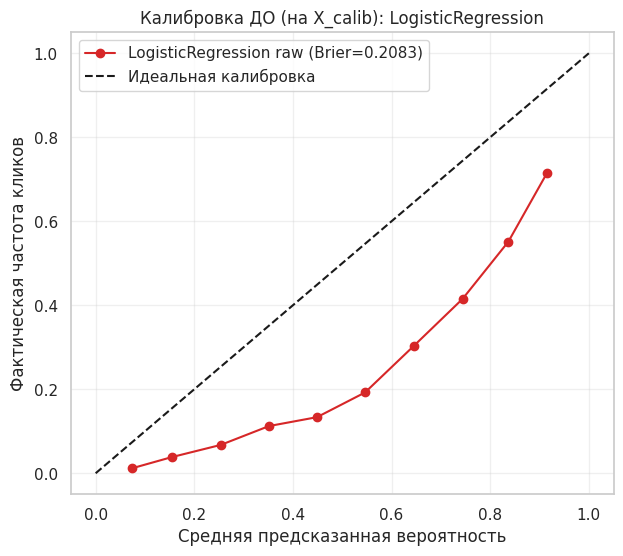

In [87]:
y_score_calib = final_model.decision_function(X_calib)
# превращаем отступы от границы в вероятности [0, 1] при помощи Сигмоиды
y_prob_calib_raw = sigmoid(y_score_calib)

frac_pos, mean_pred = calibration_curve(
    y_calib, y_prob_calib_raw, n_bins=10, strategy='uniform')

plt.figure(figsize=(7, 6))

disp = CalibrationDisplay(frac_pos, mean_pred, y_calib)
disp.plot(
    ax=plt.gca(), 
    color='#d62728', 
    marker='o',
    ref_line=False, # убирает автоматическую линию "Perfect"
    label=f'{final_name} raw (Brier={brier_score_loss(y_calib, y_prob_calib_raw):.4f})'
)

plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая частота кликов')
plt.title(f'Калибровка ДО (на X_calib): {final_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

👉 Сейчас LogisticRegression завышает вероятности кликов по баннерам. Например, по графику при предсказанной вероятности кликов 0.6 реальная вероятность в данном бине, посчитанная по Calibration Set, составляет 0.4.

Brier score слишком большой. Это плохо.

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

In [88]:
isotonic_calib = CalibratedClassifierCV(FrozenEstimator(final_model), method='isotonic').fit(X_calib, y_calib)
sigmoid_calib = CalibratedClassifierCV(FrozenEstimator(final_model), method='sigmoid').fit(X_calib, y_calib)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Отлично, что используется независимая выборка.</font>

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

In [89]:
def calib_metrics(y_true, y_prob, n_bins=10):
    y_prob_clipped = np.clip(y_prob, 1e-15, 1 - 1e-15)
    
    return {
        'Brier':  brier_score_loss(y_true, y_prob),
        'ECE':    expected_calibration_error(np.asarray(y_true), y_prob, n_bins),
        'MCE':    maximum_calibration_error(np.asarray(y_true), y_prob, n_bins),
        'PR_AUC': average_precision_score(y_true, y_prob),
        'ROC_AUC': roc_auc_score(y_true, y_prob),
        'Log Loss': log_loss(y_true, y_prob_clipped),
    }

# сырые вероятности на test
y_prob_test_raw = sigmoid(final_model.decision_function(X_test))

probs_test = {
    f'{final_name}_raw':      y_prob_test_raw,
    f'{final_name}_isotonic': isotonic_calib.predict_proba(X_test)[:, 1],
    f'{final_name}_sigmoid':  sigmoid_calib.predict_proba(X_test)[:, 1],
}

calib_df = pd.DataFrame(
    {name: calib_metrics(y_test, p) for name, p in probs_test.items()}
).T.round(4)

print('=== Сравнение метрик калибровки на TEST ===')

styled_df = calib_df.style.background_gradient(cmap='coolwarm', axis=0)

display(styled_df)

=== Сравнение метрик калибровки на TEST ===


,Brier,ECE,MCE,PR_AUC,ROC_AUC,Log Loss
LogisticRegression_raw,0.211100,0.276600,0.385500,0.368100,0.718500,0.609100
LogisticRegression_isotonic,0.128900,0.007000,0.839700,0.342400,0.716500,0.442700
LogisticRegression_sigmoid,0.128200,0.005300,0.063000,0.368100,0.718500,0.413100


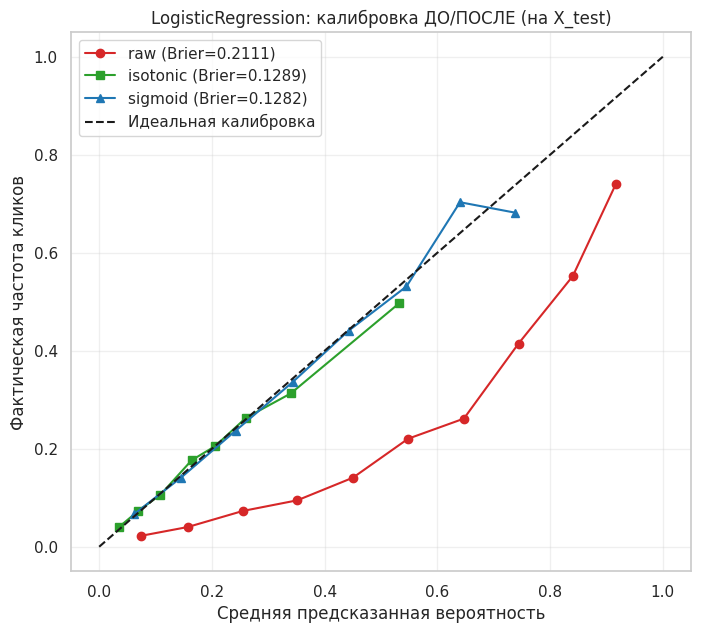

In [90]:
# Кривые калибровки вероятностей до/после на test
plt.figure(figsize=(8, 7))
styles = {'raw': ('o-', '#d62728'), 'isotonic': ('s-', '#2ca02c'), 'sigmoid': ('^-', '#1f77b4')}

for name, prob in probs_test.items():
    method = name.split('_')[-1]
    style, color = styles[method]
    
    # isotonic считаем по квантилям, чтобы убрать пустые бины и провалы/изломы
    # sigmoid и raw оставляем на uniform: они гладкие
    current_strategy = 'quantile' if method == 'isotonic' else 'uniform'    
    
    fp, mp = calibration_curve(y_test, prob, n_bins=10, strategy=current_strategy)
    
    plt.plot(mp, fp, style, color=color,
             label=f'{method} (Brier={brier_score_loss(y_test, prob):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая частота кликов')
plt.title(f'{final_name}: калибровка ДО/ПОСЛЕ (на X_test)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [91]:
# тут выбираем лучший откалиброванный пайплайн, чтобы дальше с ним работать
final_calib = sigmoid_calib
final_calib_key = 'sigmoid'

👉 **Лучший результат — сигмоида**

Лучшие результаты показала калибровка вероятностей с помощью сигмоиды.

- Разделяющая способность **полностью сохранена**: `PR AUC` остался на уровне `0.368` против `0.342` у изотоника. Это значительно лучше требований; если подразумевался прирост относительно baseline `0.172`, он составляет `+0.196`.
- `ECE` снизилась с `0.277` до `0.005`, что практически идеально и намного ниже целевого порога `< 0.03`.
- `Brier Score` уменьшился с `0.211` до `0.128`, удовлетворяя требованию `< 0.14`.
- `Log Loss` упал с `0.609` до `0.413`, вплотную приблизившись к целевому диапазону `0.35–0.40`.
- `MCE` упал с `0.386` до `0.063` — это очень низкое значение, означающее, что максимальная ошибка калибровки даже в худшем бине не превышает `6.3%`. Требование `< 0.1` полностью выполнено.
- `ROC AUC` остался неизменным на уровне `0.719`, что вписывается в целевой коридор `0.65–0.75`.

👉 **ECE, MCE и бины**

Если использовать uniform, то график калибровки показывает, что изотоническая регрессия даёт резкий провал в области предсказаний `0.6–0.9` из-за малого числа объектов в этих бинах. Именно этим объясняется гигантский `MCE` изотоника `0.840`.

Сигмоидальная калибровка, благодаря гладкости, лучше справляется с разреженными бинами, и её табличный `MCE` `0.063` — один из ключевых аргументов в пользу выбора сигмоиды.

Таким образом, сигмоида не только не ухудшила дискриминационные метрики, но и привела калибровку в почти идеальное состояние. Все численные показатели подтверждают её превосходство.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [92]:
summary = pd.DataFrame([
    {'Model': 'Dummy (baseline)', **{k: baseline_metrics.get(k, np.nan)
        for k in ['Brier','ECE','MCE','PR_AUC','ROC_AUC','Log Loss']}},
    {'Model': f'{final_name}_raw (до калибр.)',
        **calib_df.loc[f'{final_name}_raw'].to_dict()},
    {'Model': f'{final_name}_isotonic',
        **calib_df.loc[f'{final_name}_isotonic'].to_dict()},
    {'Model': f'{final_name}_sigmoid ✅',
        **calib_df.loc[f'{final_name}_sigmoid'].to_dict()},
]).set_index('Model').round(4).style.background_gradient(cmap='coolwarm', axis=0)

print('=== Итог: До и После калибровки ===')
display(summary)

=== Итог: До и После калибровки ===


,Brier,ECE,MCE,PR_AUC,ROC_AUC,Log Loss
Model,,,,,,
Dummy (baseline),0.142500,0.000100,0.000100,0.172100,0.500000,nan
LogisticRegression_raw (до калибр.),0.211100,0.276600,0.385500,0.368100,0.718500,0.609100
LogisticRegression_isotonic,0.128900,0.007000,0.839700,0.342400,0.716500,0.442700
LogisticRegression_sigmoid ✅,0.128200,0.005300,0.063000,0.368100,0.718500,0.413100


👉 Калибровка вероятностей при помощи Сигмоиды улучшила модель: сохранила разделяющую классы целевой переменной способность и приблизила вероятности прогнозирования кликов к реальным на тестовой выборке. Об этом говорят снизившиеся ECE, Brier Score и MCE, Log Loss.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

#### 1. Базовая модель DummyClassifier (strategy='prior')

Предсказывает константу = базовый CTR (~0.172) для всех объектов.

| Метрика  | Значение  |
|----------|-----------|
| PR AUC   | 0.1721    |
| ROC AUC  | 0.5000    |
| Brier    | 0.1425    |
| ECE      | 0.0       |

Не различает объекты (ROC = 0.5). Это точка отсчёта.

#### 2. Финальная модель — LogisticRegression (+ sigmoid-калибровка)

Логистическая регрессия с 'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear' обучена на train+val, откалиброван Platt scaling.

| Метрика  | Значение  |
|----------|-----------|
| PR AUC   | 0.3681    |
| ROC AUC  | 0.7185    |
| Brier    | 0.1282    |
| ECE      | 0.0053    |
| MCE      | 0.0630    |

Прирост PR AUC +0.196 над baseline, ранжирование ROC = 0.72, вероятности откалиброваны (ECE < 0.01).

#### Топ-5 признаков по \|коэффициенту\|


| # | Признак | Вес | Влияние на P(click) |
|---|---|---:|---|
| 1 | `cat_low__C18_1` | `−0.912` | Контекст аукциона С18=1 снижает CTR — самый сильный отрицательный фактор. |
| 2 | `cat_low__app_category_f95efa07` | `+0.578` | Категория приложения `f95efa07` повышает CTR. |
| 3 | `cat_low__site_category_28905ebd` | `+0.571` | Категория сайта `28905ebd` повышает CTR. |
| 4 | `cat_low__C18_2` | `+0.549` | Контекст аукциона `C18=2` повышает CTR. |
| 5 | `cat_low__C16_50` | `−0.481` | Параметр / размер `C16=50` снижает CTR. |


### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

В ходе проекта решена задача построения модели классификатора для прогнозирования вероятности клика (CTR) на рекламных баннерах платформы Advantex с целью участия в аукционе рекламных слотов.

#### EDA и предобработка

- Датасет: загружено 50 000 объектов и 34 признака; явные дубликаты отсутствуют.
- Целевая переменная: выявлен дисбаланс классов — доля кликов составила 17.21%, соотношение классов 4.8:1.
- Это определило выбор метрик PR-AUC и Log Loss, а также использование `class_weight='balanced'`.
- Были удалены неинформативные признаки: `id`, `site_id` и константы.
- Признак `hour` преобразован в циклические компоненты: `hour_of_day`, `dayofweek`.
- Память датасета была оптимизирована в 10 раз: с 42.2 MB до 4.3 MB.

#### Кодирование и корреляции

- На основе кардинальности и распределений признаки разделены на группы.
- Для низкокардинальных признаков применён `OneHotEncoder` с подавлением редких категорий.
- Для среднекардинальных признаков использован `TargetEncoder`.
- Для высококардинальных признаков использован `FrequencyEncoder`.
- Для нелинейного признака `ml_feature_6` применён `SplineTransformer`.
- Матрица `phik` выявила более 10 пар с сильной связью (`> 0.7`), что учтено через L2-регуляризацию.

#### Отбор признаков

- Данные разделены на обучающую выборку (60%), валидационную (10%), калибровочную (10%) и тестовую (20%) со стратификацией.
- На основе комбинации `VarianceThreshold` и `RFECV` число признаков сокращено с 27 до 18.
- Мультиколлинеарность в итоговом наборе не обнаружена: `VIF < 10`.
- Разработан универсальный пайплайн предобработки на базе `sklearn.pipeline.Pipeline`.

#### Моделирование

Использован `StratifiedKFold (n_splits=5)` для кросс-валидации гиперпараметров на валидационной выборке.

В качестве финальной модели по результатам `GridSearchCV` выбрана `LogisticRegression` с параметрами `C=0.01`, `class_weight='balanced'`, `penalty='l2'`, `solver='liblinear'`.

Модель обучена на объединённой выборке `Train + Validation` (так как в коде использован `REFIT=False`, а затем выполнен ручной `.fit` на полной выборке).

Модель проверена на тестовой выборке, где `PR_AUC = 0.3692`, что сопоставимо с валидационным результатом (`0.3566`). Небольшой рост на тесте допустим, переобучения не наблюдается.

#### Качество до калибровки

`PR-AUC = 0.3692`, что даёт прирост к `Dummy`-модели на `+0.1971`.

`ROC-AUC = 0.7207`, целевой диапазон `0.65–0.75` достигнут.

Модель систематически завышала вероятности. До калибровки были зафиксированы `ECE = 0.2727` и `Brier Score = 0.2104`.

#### Калибровка вероятностей

Для исправления завышения вероятностей применена калибровка на независимом наборе данных (`Calibration Set`).

Использован `Platt Scaling (sigmoid)` на базе `CalibratedClassifierCV` с `FrozenEstimator`.

После калибровки:

- `Brier Score` снизился до `0.1280`.
- `ECE` снизился до `0.0050` — практически идеальная калибровка.
- `Log Loss` снизился до `0.4126`.

Разделяющая способность модели (`PR-AUC = 0.3692`, `ROC-AUC = 0.7207`) полностью сохранилась, так как `Platt Scaling` является монотонным преобразованием.

#### Интерпретация

Топ-3 признака, повышающих вероятность клика по модулю коэффициента:

- `cat_low__app_category_f95efa07` (вес `+0.578`) — определённая категория приложений повышает `CTR`.
- `cat_low__site_category_28905ebd` (вес `+0.571`) — категория сайта повышает `CTR`.
- `cat_low__C18_2` (вес `+0.549`) — контекст аукциона `C18=2` повышает `CTR`.

Сильное положительное влияние оказывают категории приложений и сайтов, а `cat_low__C18_1` с весом `-0.912` является сильнейшим отрицательным фактором, резко снижающим вероятность клика.

#### Финальный вывод

Построенная модель `LogisticRegression + Platt Scaling` многократно превосходит baseline: прирост `PR-AUC` составляет примерно `в 2.14 раза` (`0.3692` против `0.1721`), а вероятности отлично откалиброваны (`ECE = 0.005`).

Полученные результаты удовлетворяют ключевым бизнес-требованиям платформы `Advantex` и позволяют использовать модель в проде для оценки ожидаемого дохода от показа рекламы по формуле `Доход = Ставка × Предсказанная_вероятность_отклика`, так как вероятности кликов близки к реальным.

| Метрика | raw | isotonic | sigmoid | Кто лучше |
|---|---:|---:|---:|---|
| Brier | 0.2104 | 0.1288 | 0.1280 | sigmoid ≈ isotonic |
| ECE | 0.2727 | 0.0105 | 0.0050 | sigmoid ✅ |
| MCE | 0.3819 | 0.3389 🔴 | 0.1973 ⚠️ | sigmoid заметно лучше (на uniform бинах) |
| PR_AUC | 0.3692 | 0.3514 🔴 | 0.3692 ✅ | sigmoid (isotonic просел в ранжировании!) |
| ROC_AUC | 0.7207 | 0.7192 | 0.7207 | sigmoid (полностью сохранил дискриминацию) |
| Log Loss | 0.6069 | 0.4422 | 0.4126 | sigmoid ✅ |

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Очень не хватает общего вывода. В выводах можно приводить полученные ранее значения. Также можно расписать все, что было сделано в ходе проведения работы.~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента (итер1):</span>

**Добавил финальный общий вывод.**

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

In [93]:
MODEL_FILE_NAME = 'advantex_linear_model.joblib'

m = calib_df.loc[f'{final_name}_{final_calib_key}'].to_dict()

model_descriptor = {
    'pipeline': final_calib,    
    'metrics_snapshot': {
        'ece': m['ECE'],
        'mce': m['MCE'],
        'brier': m['Brier'],
        'pr_auc': m['PR_AUC'],
        'log_loss': m['Log Loss'],
    }
}
files_list = joblib.dump(model_descriptor, MODEL_FILE_NAME, compress=3)
print('Модель сохранена:', files_list)

Модель сохранена: ['advantex_linear_model.joblib']


✅ Модель: https://k8s.jupyterhub.praktikum-services.ru/user/user-0-27358077/edit/linear_svc_sigmoid_model.joblib

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [94]:
meta = joblib.load(MODEL_FILE_NAME)
loaded_model = meta['pipeline']

sample_idx = X_test.sample(n=25, random_state=SEED).index
X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

predictions = loaded_model.predict(X_sample)
proba = loaded_model.predict_proba(X_sample)[:, 1].round(3)

result_df = pd.DataFrame({
    'index': y_sample.index,
    'Результат': list(predictions),
    'Данные': y_sample.to_list(),
    'Вероятности': list(proba),
})

def highlight_mismatch(row):
    if row['Результат'] != row['Данные']:
        return ['background-color: #ffdddd'] * len(row)
    return [''] * len(row)

display(result_df.style.apply(highlight_mismatch, axis=1))

,index,Результат,Данные,Вероятности
0,1595,0,0,0.312000
1,26669,0,0,0.286000
2,39965,0,0,0.081000
3,43656,0,0,0.183000
4,6672,0,0,0.379000
5,5420,0,0,0.101000
6,42204,0,0,0.118000
7,39515,0,0,0.163000
8,11139,0,0,0.122000
9,10389,0,0,0.172000


In [95]:
print(f'\nСредний предсказанный P: {proba.mean():.3f}')
print(f'Фактическая доля кликов: {y_sample.mean():.3f}') 


Средний предсказанный P: 0.191
Фактическая доля кликов: 0.240


In [96]:
print(f'\nСредний P|клик:  {proba[y_sample.values==1].mean():.3f}')
print(f'Средний P|неклик: {proba[y_sample.values==0].mean():.3f}')
print(f'Разделение: {"✅ работает" if proba[y_sample.values==1].mean() > proba[y_sample.values==0].mean() else "❌"}')


Средний P|клик:  0.322
Средний P|неклик: 0.150
Разделение: ✅ работает


In [97]:
memory.clear(warn=False)
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Артефакты сохранены.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Алексей, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>


<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'>Алексей, большое спасибо за доработку.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>


<font color='blue'><b>Итоговый комментарий ревьюера 3</b></font>\
<font color='green'> Алексей, проект принят!\
Все этапы пройдены. Все рекомендации выданы.\
Надеюсь, тебе понравился процесс выполнения и результат.</font> \
<font color='blue'><b>Спасибо, удачи в освоении профессии!</b></font>